In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !git clone --depth 1 https://github.com/deepinsight/insightface.git '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/insightface'

Cloning into '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/insightface'...
remote: Enumerating objects: 1758, done.
remote: Counting objects: 100% (1758/1758), done.
remote: Compressing objects: 100% (1450/1450), done.
remote: Total 1758 (delta 268), reused 1281 (delta 221), pack-reused 0 (from 0)
Receiving objects: 100% (1758/1758), 26.06 MiB | 10.98 MiB/s, done.
Resolving deltas: 100% (268/268), done.
Updating files: 100% (1485/1485), done.


# FAISS_demo

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 53.8 MB/s eta 0:00:00


In [ ]:
!pip install numpy opencv-python insightface onnxruntime-gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 5.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 70.2 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071482 sha256=c01f4f1789e041b844a9c8fd1829e5201afcad5fa5c21a46558e5b21d21693fa
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface


In [ ]:
import os
import numpy as np
import faiss
from pathlib import Path
from insightface.app import FaceAnalysis

# ── 모델 초기화
app = FaceAnalysis(
    name='buffalo_l',           # 가장 정확한 pretrained 모델
    allowed_modules=['detection', 'recognition']
)
app.prepare(ctx_id=0)          # GPU: 0, CPU: -1

# ──────────────────────────────────────────
# 1. 단일 이미지 → 임베딩 추출
# ──────────────────────────────────────────
def get_embedding(img_path):
    """
    이미지 경로 → 512-d 임베딩
    얼굴 감지 실패 시 None 반환
    """
    import cv2
    img   = cv2.imread(str(img_path))
    faces = app.get(img)

    if not faces:
        print(f'  [경고] 얼굴 감지 실패: {img_path}')
        return None

    if len(faces) > 1:
        # 여러 얼굴 → 가장 큰 얼굴 선택
        faces = sorted(faces, key=lambda f: f.bbox[2] * f.bbox[3], reverse=True)

    emb = faces[0].embedding                        # (512,) float32
    emb = emb / np.linalg.norm(emb)                 # L2 정규화
    return emb


# ──────────────────────────────────────────
# 2. 인물별 지문 벡터 생성 → FAISS DB 구축
# ──────────────────────────────────────────
def build_faiss_db(dataset_root, enroll_per_person=15):
    """
    dataset_root/
        person_A/
            01.jpg ~ 15.jpg
        person_B/
            ...

    return: index, names
    """
    names   = []
    vectors = []

    for person_dir in sorted(Path(dataset_root).iterdir()):
        if not person_dir.is_dir():
            continue

        name      = person_dir.name
        img_paths = sorted(person_dir.glob('*.jpg'))[:enroll_per_person]

        # png도 포함하려면
        # img_paths = sorted([
        #     p for p in person_dir.iterdir()
        #     if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
        # ])[:enroll_per_person]

        embs = []
        for img_path in img_paths:
            emb = get_embedding(img_path)
            if emb is not None:
                embs.append(emb)

        if len(embs) == 0:
            print(f'  [스킵] {name}: 유효한 얼굴 없음')
            continue

        if len(embs) < enroll_per_person:
            print(f'  [경고] {name}: {len(embs)}장만 등록 ({enroll_per_person}장 목표)')

        # 평균 → L2 정규화 → 지문 벡터
        mean_emb = np.mean(embs, axis=0)
        mean_emb = mean_emb / np.linalg.norm(mean_emb)

        names.append(name)
        vectors.append(mean_emb)
        print(f'  등록 완료: {name} ({len(embs)}장)')

    if not vectors:
        raise ValueError('등록된 인물이 없습니다. 경로를 확인하세요.')

    # FAISS 인덱스 생성
    dim      = 512
    index    = faiss.IndexFlatIP(dim)               # 내적 = 코사인 유사도 (L2정규화 후)

    db_mat   = np.stack(vectors).astype('float32')  # (N, 512)
    faiss.normalize_L2(db_mat)                       # 안전하게 한 번 더 정규화
    index.add(db_mat)

    print(f'\nFAISS DB 구축 완료: {index.ntotal}명')
    return index, names


# ──────────────────────────────────────────
# 3. 저장 / 로드
# ──────────────────────────────────────────
def save_db(index, names, index_path='/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/face_db.index', names_path='face_db_names.npy'):
    faiss.write_index(index, index_path)
    np.save(names_path, np.array(names))
    print(f'저장 완료: {index_path}, {names_path}')

def load_db(index_path='/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/face_db.index', names_path='face_db_names.npy'):
    index = faiss.read_index(index_path)
    names = np.load(names_path, allow_pickle=True).tolist()
    print(f'로드 완료: {index.ntotal}명')
    return index, names


# ──────────────────────────────────────────
# 4. 1:N 인식
# ──────────────────────────────────────────
def identify(img_path, index, names, threshold=0.35):
    """
    return: (name, score)
    score < threshold → 'unknown'
    """
    emb = get_embedding(img_path)

    if emb is None:
        return 'unknown', 0.0

    query = emb.astype('float32').reshape(1, -1)
    faiss.normalize_L2(query)

    D, I        = index.search(query, k=1)
    best_score  = float(D[0][0])
    best_name   = names[I[0][0]]

    if best_score < threshold:
        return 'unknown', best_score

    return best_name, best_score


# ──────────────────────────────────────────
# 5. 배치 평가
# ──────────────────────────────────────────
def evaluate(index, names, attack_set_root, threshold=0.35):
    """
    attack_set_root/
        person_A/
            16.jpg ~ 40.jpg   (enrollment에 안 쓴 이미지)
        person_B/
            ...
    """
    import pandas as pd

    correct, total = 0, 0
    results        = []

    for person_dir in sorted(Path(attack_set_root).iterdir()):
        if not person_dir.is_dir():
            continue

        true_name      = person_dir.name
        img_paths      = sorted(person_dir.glob('*.jpg'))
        person_correct = 0

        for img_path in img_paths:
            pred_name, score = identify(img_path, index, names, threshold)
            if pred_name == true_name:
                correct        += 1
                person_correct += 1
            total += 1

        acc = person_correct / len(img_paths) if img_paths else 0
        results.append({
            'name':     true_name,
            'total':    len(img_paths),
            'correct':  person_correct,
            'accuracy': acc
        })
        print(f'  {true_name}: {person_correct}/{len(img_paths)} ({acc:.2%})')

    overall_acc = correct / total if total > 0 else 0
    print(f'\n전체 Rank-1 정확도: {overall_acc:.4f} ({correct}/{total})')

    df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
    return overall_acc, df


# ──────────────────────────────────────────
# 실행
# ──────────────────────────────────────────
if __name__ == '__main__':

    # DB 구축
    index, names = build_faiss_db('/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/한국연예인_Enrollment', enroll_per_person=15)
    save_db(index, names)

    # 단일 인식 테스트
    name, score = identify('/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/한국연예인_AttackSet/류진/류진_옆모습_23.jpg', index, names)
    print(f'인식 결과: {name} (유사도: {score:.4f})')

    # 전체 평가
    acc, df = evaluate(index, names, '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/한국연예인_AttackSet')
    print(df)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_l/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
  등록 완료: 김고은 (15장)
  등록 완료: 나재민 (15장)
  등록 완료: 남궁민 (15장)
  등록 완료: 류진 (15장)
 

In [ ]:
!mv ./face_db_names.npy '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'

In [ ]:
!ls -al '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'

total 182
-rw-------   1 root root  8527 May 10 02:55  Crawling.ipynb
-rw-------   1 root root 41005 May 10 10:43  face_db.index
-rw-------+  1 root root  1328 May 10 10:43  face_db_names.npy
-rw-------   1 root root 21916 May 10 02:40  face_detection.ipynb
-rw-------   1 root root 26456 May 10 10:54 'FR_w FAISS.ipynb'
drwx------   3 root root  4096 May  6 11:31 'Labelled Faces in the Wild (LFW) Dataset'
drwx------   4 root root  4096 May  8 18:10  데이터셋
-rw-------   1 root root 56704 May  9 18:44 '데이터 수집.ipynb'
drwx------   2 root root  4096 May  9 15:17 '안 중요'
drwx------   2 root root  4096 May  8 17:38  카리나
drwx------   2 root root  4096 May  9 17:18 '한국 연예인'
drwx------  22 root root  4096 May  9 17:37  한국연예인_AttackSet
drwx------  22 root root  4096 May  9 17:37  한국연예인_Enrollment
-rw-------   1 root root   311 May  9 11:13 '한국 연예인.txt'


In [ ]:
import faiss
import numpy as np
from pathlib import Path

def build_faiss_db(model, dataset_root, enroll_per_person=15):
    """
    기존 build_db()와 동일한 구조
    numpy DB 대신 FAISS 인덱스로 저장
    """
    names    = []
    vectors  = []

    for person_dir in sorted(Path(dataset_root).iterdir()):
        if not person_dir.is_dir():
            continue

        name      = person_dir.name
        img_paths = sorted(person_dir.glob('*.jpg'))[:enroll_per_person]

        if not img_paths:
            continue

        # 임베딩 추출 (15, 512)
        embeddings = extract_batch(model, img_paths)

        # 평균 → L2 정규화 → 지문 벡터
        mean_emb = embeddings.mean(axis=0)
        mean_emb = mean_emb / np.linalg.norm(mean_emb)

        names.append(name)
        vectors.append(mean_emb)
        print(f'  등록: {name} ({len(img_paths)}장)')

    # FAISS 인덱스 생성
    dim        = 512
    index      = faiss.IndexFlatIP(dim)  # 내적 기반 (L2정규화 후 = 코사인 유사도)

    db_matrix  = np.stack(vectors).astype('float32')  # (N, 512)
    faiss.normalize_L2(db_matrix)                      # 한번 더 정규화 (안전하게)
    index.add(db_matrix)

    print(f'\n총 {index.ntotal}명 등록 완료')

    return index, names  # 인덱스 + 이름 리스트 함께 반환


# 실행
index, names = build_faiss_db(model, 'dataset/enroll')

# face_embedder 모듈화 확인

In [ ]:
import os

WEIGHT_ROOT = '/content/drive/MyDrive/안인지'

for f in sorted(os.listdir(WEIGHT_ROOT)):
    print(f)

In [ ]:
!git clone --depth 1 https://github.com/deepinsight/insightface.git /content/insightface

Cloning into '/content/insightface'...
remote: Enumerating objects: 1758, done.
remote: Counting objects: 100% (1758/1758), done.
remote: Compressing objects: 100% (1460/1460), done.
remote: Total 1758 (delta 259), reused 1283 (delta 211), pack-reused 0 (from 0)
Receiving objects: 100% (1758/1758), 26.07 MiB | 25.35 MiB/s, done.
Resolving deltas: 100% (259/259), done.


In [ ]:
!cp '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/face_embedder.py' /content

In [ ]:
!mv /content/insightface '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/'

^C


In [ ]:
!ls /content

drive  face_embedder.py  insightface  sample_data


In [ ]:
# 1. 현재 코랩의 작업 디렉토리를 face_embedder.py가 있는 폴더로 변경합니다.
# (ls -al을 실행했을 때 위 파일 목록이 나왔던 그 폴더 경로를 적어주셔야 합니다!)
# 예시: '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
current_working_dir = '/content'

if os.path.exists(current_working_dir):
    os.chdir(current_working_dir)
    print(f"✅ 작업 디렉토리가 성공적으로 변경되었습니다: {os.getcwd()}")
else:
    print("❌ 경로가 올바르지 않습니다. 구글 드라이브 마운트 및 폴더 경로를 다시 확인해주세요.")

# 2. 파이썬 모듈 검색 경로에 해당 디렉토리를 추가합니다.
if current_working_dir not in sys.path:
    sys.path.insert(0, current_working_dir)

✅ 작업 디렉토리가 성공적으로 변경되었습니다: /content


In [ ]:
import time
import os
import sys

start = time.time()
# # 1. 현재 코랩의 작업 디렉토리를 face_embedder.py가 있는 폴더로 변경합니다.
# # (ls -al을 실행했을 때 위 파일 목록이 나왔던 그 폴더 경로를 적어주셔야 합니다!)
# # 예시: '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
# current_working_dir = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'

# if os.path.exists(current_working_dir):
#     os.chdir(current_working_dir)
#     print(f"✅ 작업 디렉토리가 성공적으로 변경되었습니다: {os.getcwd()}")
# else:
#     print("❌ 경로가 올바르지 않습니다. 구글 드라이브 마운트 및 폴더 경로를 다시 확인해주세요.")

# # 2. 파이썬 모듈 검색 경로에 해당 디렉토리를 추가합니다.
# if current_working_dir not in sys.path:
#     sys.path.insert(0, current_working_dir)

# 3. 이제 불러오기를 시도합니다.
from face_embedder import FaceEmbedder
print("complete")

# 1. 가중치 파일 경로 설정 (가장 성능이 좋았던 cos_r100_fp16 모델 추천)
WEIGHT_PATH = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/arc_r18_fp16_backbone.pth'

# 2. 임베딩 추출기 객체 생성 (자동으로 CUDA 감지 및 가중치 주입 완료)
embedder = FaceEmbedder(weight_path=WEIGHT_PATH)

# 2. 이미지가 모여있는 폴더 경로 지정
# (지정한 폴더 하위의 모든 폴더까지 알아서 탐색합니다.)
FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/한국 연예인_전처리/한국연예인_Enrollment/김고은'

# 3. 자동으로 폴더 내의 이미지 경로 수집하기
test_images = embedder.get_image_paths(FOLDER_PATH)
print(f"🔎 발견된 총 이미지 개수: {len(test_images)}개")

# 4. 임베딩 추출 실행
if test_images:
    embeddings = embedder.extract_batch(test_images, batch_size=64)
    print("✨ 임베딩 추출 완료! 행렬 크기:", embeddings.shape)
else:
    print("❌ 지정한 폴더 내에 이미지 파일이 존재하지 않습니다.")
print(f"{(time.time()-start) / 60} 분")

complete
🔎 발견된 총 이미지 개수: 15개


/content/insightface/recognition/arcface_torch/backbones/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


✨ 임베딩 추출 완료! 행렬 크기: (15, 512)
0.12115976015726725 분


In [ ]:
embeddings

array([[-0.00673664,  0.01927782, -0.05014865, ...,  0.00981058,
         0.07620478,  0.01861243],
       [ 0.05929672, -0.00385002, -0.00683869, ...,  0.03359889,
         0.03350973,  0.01064681],
       [-0.01945634, -0.03356318, -0.03804078, ..., -0.04732905,
         0.08788743,  0.02077697],
       ...,
       [ 0.01074672, -0.03956096, -0.06265884, ...,  0.01617329,
         0.0700862 ,  0.06023425],
       [ 0.04761178, -0.0389584 , -0.08317409, ...,  0.02520914,
         0.06044839,  0.04337786],
       [ 0.02282444,  0.02367755, -0.02093667, ...,  0.04642321,
         0.04475977,  0.02985464]], dtype=float32)

In [ ]:
import numpy as np

def make_fingerprint_vector(embeddings):
    """
    여러 개의 얼굴 임베딩 벡터들을 하나의 대표 지문 벡터로 병합합니다.

    Args:
        embeddings (np.ndarray): (N, 512) 크기의 임베딩 행렬
    Returns:
        np.ndarray: (512,) 크기의 최종 지문 벡터
    """
    # 1. 15개 벡터의 차원별 평균(Mean)을 계산합니다. -> 결과 크기: (512,)
    mean_vector = np.mean(embeddings, axis=0)

    # 2. 평균 벡터의 L2 Norm(길이)을 구합니다.
    l2_norm = np.linalg.norm(mean_vector)

    # 3. L2 정규화를 수행하여 최종 길이를 1로 맞춰줍니다.
    # (혹시 모를 0 나누기 방지를 위해 아주 작은 값인 1e-10을 더해줍니다)
    fingerprint_vector = mean_vector / (l2_norm + 1e-10)

    return fingerprint_vector

# --- 실제 적용 예시 ---
# 추출하신 (15, 512) 크기의 embeddings 변수를 넣습니다.
fingerprint = make_fingerprint_vector(embeddings)

print("원본 임베딩 행렬 크기:", embeddings.shape)     # 출력: (15, 512)
print("최종 지문 벡터 크기:", fingerprint.shape)       # 출력: (512,)
print("지문 벡터의 L2 길이(1이 나와야 정상):", np.linalg.norm(fingerprint)) # 출력: 1.0

원본 임베딩 행렬 크기: (15, 512)
최종 지문 벡터 크기: (512,)
지문 벡터의 L2 길이(1이 나와야 정상): 1.0


In [ ]:
Qembeddings = embedder.extract_batch(["/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/한국 연예인_전처리/한국연예인_AttackSet/김고은/김고은_옆모습_41_face_0.jpg"], batch_size=64)
print(Qembeddings)

[[ 0.06107306  0.004002   -0.00583938 -0.00373314 -0.00964956  0.07231297
  -0.01157534 -0.00606108  0.02111026  0.03352172 -0.04738477  0.04569795
  -0.003896   -0.00992524 -0.03320026 -0.02083917 -0.0354878   0.04409655
   0.02488093 -0.10078692  0.06665543 -0.01176878  0.00175144 -0.03554605
  -0.01695325 -0.00185964  0.02714162  0.03256938 -0.00453962 -0.02219722
   0.02903321  0.0042398   0.07285168 -0.07152997 -0.03576563  0.05120905
   0.0152214  -0.00603063 -0.01924317 -0.00173472 -0.05428085 -0.04460361
  -0.04433776  0.00460362 -0.01044345  0.03354069 -0.03249436  0.03111475
  -0.02504392 -0.0700082   0.02169986  0.03256327 -0.03758832  0.09736287
  -0.02726665  0.00516005 -0.00448235  0.05890153 -0.03114561  0.04265794
  -0.00875312  0.04168876 -0.02400636 -0.06556679 -0.00898056 -0.01340532
  -0.00018607 -0.03185867 -0.07253822  0.0179145  -0.03218719  0.03851359
  -0.04156027 -0.0047866   0.04008419  0.00778088 -0.03026615 -0.05459315
  -0.13355167  0.07384565 -0.02088984 

In [ ]:
import numpy as np

# 1. 2차원 행렬(1, 512)에서 첫 번째 데이터만 꺼내어 1차원 벡터(512,)로 만듭니다.
query_vector = Qembeddings[0]

# 2. 두 벡터의 내적(Dot Product)을 구합니다. (L2 정규화가 되어 있어 이 값이 곧 코사인 유사도입니다!)
cosine_similarity = np.dot(query_vector, fingerprint)

print(f"두 벡터의 코사인 유사도: {cosine_similarity:.4f}")

두 벡터의 코사인 유사도: 0.7616


In [ ]:
!ls -al

total 255303
-rw-------   1 root root 261223796 May 10 12:35  cos_r100_fp16_backbone.pth
-rw-------   1 root root      8527 May 10 02:55  Crawling.ipynb
-rw-------   1 root root     41005 May 10 10:43  face_db.index
-rw-------+  1 root root      1328 May 10 10:43  face_db_names.npy
-rw-------   1 root root     21916 May 10 02:40  face_detection.ipynb
-rw-------   1 root root      6000 May 10 12:56  face_embedder.py
-rw-------   1 root root     35621 May 10 12:57 'FR_w FAISS.ipynb'
drwx------   3 root root      4096 May  6 11:31 'Labelled Faces in the Wild (LFW) Dataset'
drwx------   2 root root      4096 May 10 12:51  __pycache__
drwx------   4 root root      4096 May  8 18:10  데이터셋
-rw-------   1 root root     56704 May  9 18:44 '데이터 수집.ipynb'
drwx------   2 root root      4096 May  9 15:17 '안 중요'
drwx------   2 root root      4096 May  8 17:38  카리나
drwx------   2 root root      4096 May  9 17:18 '한국 연예인'
drwx------  22 root root      4096 May  9 17:37  한

In [ ]:
# face_embedder.py 파일을 완전히 FP32(Float) 표준 연산으로 변경하여 다시 씁니다.
code_content = """import os
import sys
import glob
import torch
import torch.nn as nn
import numpy as np
import torchvision.transforms as T
from PIL import Image

# 1. InsightFace 깃허브 코드 경로 연동
BASE_DIR = os.path.dirname(os.path.abspath(__file__))
INSIGHTFACE_PATH = os.path.join(BASE_DIR, 'insightface', 'recognition', 'arcface_torch')

if INSIGHTFACE_PATH not in sys.path:
    sys.path.insert(0, INSIGHTFACE_PATH)

try:
    from backbones import iresnet18, iresnet34, iresnet50, iresnet100
except ImportError:
    raise ImportError(
        f"'{INSIGHTFACE_PATH}'에서 'backbones' 모듈을 찾을 수 없습니다. "
        "insightface 저장소가 올바른 폴더 구조로 클론되어 있는지 확인해주세요."
    )

BACKBONE_FN = {
    'r18':  iresnet18,
    'r34':  iresnet34,
    'r50':  iresnet50,
    'r100': iresnet100,
}

FILE_TO_DEPTH = {
    'arc_r18_fp16_backbone.pth':  'r18',
    'arc_r34_fp16_backbone.pth':  'r34',
    'arc_r50_fp16_backbone.pth':  'r50',
    'arc_r100_fp16_backbone.pth': 'r100',
    'cos_r18_fp16_backbone.pth':  'r18',
    'cos_r34_fp16_backbone.pth':  'r34',
    'cos_r50_fp16_backbone.pth':  'r50',
    'cos_r100_fp16_backbone.pth': 'r100',
}

# ArcFace 표준 이미지 전처리 파이프라인
TRANSFORM = T.Compose([
    T.Resize((112, 112)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


class FaceEmbedder:
    def __init__(self, weight_path, device=None):
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.weight_path = weight_path
        self.model = self._load_model()

    def _load_model(self):
        filename = os.path.basename(self.weight_path)
        if filename not in FILE_TO_DEPTH:
            raise ValueError(f"지원하지 않는 가중치 파일 이름입니다: {filename}")

        depth = FILE_TO_DEPTH[filename]

        # [수정] fp16=False로 설정하여 모델을 표준 Float32로 생성합니다.
        model = BACKBONE_FN[depth](fp16=False).to(self.device).eval()

        sd = torch.load(self.weight_path, map_location=self.device)
        if any(k.startswith('module.') for k in sd):
            sd = {k.replace('module.', ''): v for k, v in sd.items()}

        model.load_state_dict(sd, strict=False)

        # [수정] 혹시 모를 레이어 타입 불일치 방지를 위해 전 레이어를 float32로 캐스팅합니다.
        model = model.float()
        return model

    def get_image_paths(self, folder_path):
        extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
        image_paths = []
        for ext in extensions:
            search_pattern = os.path.join(folder_path, '**', ext)
            image_paths.extend(glob.glob(search_pattern, recursive=True))
        return sorted(list(set(image_paths)))

    @torch.no_grad()
    def extract_batch(self, img_paths, batch_size=64):
        all_embs = []
        for i in range(0, len(img_paths), batch_size):
            batch = img_paths[i:i + batch_size]
            tensors = []
            for p in batch:
                try:
                    img = Image.open(p).convert('RGB')
                    tensors.append(TRANSFORM(img))
                except Exception as e:
                    print(f"⚠️ 이미지 로드 실패 ({p}): {e}")
                    continue

            if not tensors:
                continue

            # [수정] 입력 데이터를 확실하게 .float()로 설정하여 FP32로 연산합니다.
            x = torch.stack(tensors).to(self.device).float()

            # 모델과 입력 모두 Float 상태임을 확실하게 보장합니다.
            self.model.float()

            emb = torch.nn.functional.normalize(self.model(x), dim=1)
            all_embs.append(emb.cpu().float().numpy())

        if not all_embs:
            return np.empty((0, 512), dtype=np.float32)

        return np.vstack(all_embs)
"""

# 저장 경로 설정
target_path = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/face_embedder.py"

with open(target_path, "w", encoding="utf-8") as f:
    f.write(code_content)

print(f"✅ {target_path} 에 표준 Float32 기반의 코드가 성공적으로 덮어써졌습니다!")

✅ /content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/face_embedder.py 에 표준 Float32 기반의 코드가 성공적으로 덮어써졌습니다!


In [ ]:
os.getcwd()

'/content'

# FAISS DB 구축 및 데이터 저장

In [ ]:
!ls -R '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋'

'/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋':
 ms1mv3  '한국 연예인_전처리'

'/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/ms1mv3':
extraction_summary.txt	identity_0017846  identity_0040449  identity_0064107
identity_0000883	identity_0018601  identity_0041362  identity_0067114
identity_0003968	identity_0018643  identity_0041390  identity_0067321
identity_0004627	identity_0020209  identity_0043617  identity_0074100
identity_0005354	identity_0022522  identity_0047225  identity_0074678
identity_0005757	identity_0025069  identity_0049006  identity_0074848
identity_0008192	identity_0027191  identity_0049484  identity_0079652
identity_0008721	identity_0027974  identity_0049522  identity_0081322
identity_0013050	identity_0033987  identity_0051520  identity_0088874
identity_0014983	identity_0035240  identity_0052202  MS1MV3_AttackSet
identity_0015122	identity_0037985  identity_0059567  MS1MV3_Enrollment
identity_0016492	identity_0038598  identity_0060

In [ ]:
os.getcwd()

'/content'

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 20.7 MB/s eta 0:00:00


In [ ]:
import os
import sys
import json
import numpy as np
import faiss

# ==========================================
# 1. 경로 설정
# ==========================================
WORKING_DIR  = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)

from face_embedder import FaceEmbedder

DATASET_DIR  = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋'

# 그룹별 enrollment 폴더 경로
GROUP_DIRS = {
    'korean':  os.path.join(DATASET_DIR, '한국 연예인_전처리', '한국연예인_Enrollment'),
    'western': os.path.join(DATASET_DIR, 'ms1mv3', 'MS1MV3_Enrollment'),
}

# WEIGHT_PATH        = os.path.join(WORKING_DIR, 'arc_r18_fp16_backbone.pth')
OUTPUT_INDEX_PATH  = os.path.join(WORKING_DIR, 'face_database.index')
OUTPUT_META_PATH   = os.path.join(WORKING_DIR, 'face_metadata.json')


# ==========================================
# 2. 지문 벡터 생성
# ==========================================
def make_fingerprint_vector(embeddings):
    """여러 임베딩 평균 후 L2 정규화 → 지문 벡터 1개"""
    mean_vec = np.mean(embeddings, axis=0)
    norm     = np.linalg.norm(mean_vec)
    return mean_vec / (norm + 1e-10)


# ==========================================
# 3. FAISS DB 구축
# ==========================================
def build_database(weight):
    WEIGHT_PATH        = os.path.join(WORKING_DIR, weight)
    print('⏳ 모델 로딩 중...')
    embedder = FaceEmbedder(weight_path=WEIGHT_PATH)
    print('✅ 모델 로딩 완료!\n')

    fingerprints = []   # 지문 벡터 리스트
    metadata     = {}   # {faiss_id: {'name': ..., 'group': ...}}
    current_id   = 0

    # ── 그룹별 순회
    for group, enroll_root in GROUP_DIRS.items():
        if not os.path.exists(enroll_root):
            print(f'⚠️  [{group}] 폴더 없음: {enroll_root}')
            continue

        identities = sorted([
            d for d in os.listdir(enroll_root)
            if os.path.isdir(os.path.join(enroll_root, d))
        ])
        print(f'[{group}] {len(identities)}명 발견')

        for name in identities:
            person_dir  = os.path.join(enroll_root, name)
            img_paths   = embedder.get_image_paths(person_dir)

            if not img_paths:
                print(f'  ⚠️  {name}: 이미지 없음 → 스킵')
                continue

            print(f'  ⚙️  {name}: {len(img_paths)}장 처리 중...')

            # 임베딩 추출
            embeddings = embedder.extract_batch(img_paths, batch_size=64)

            if embeddings.shape[0] == 0:
                print(f'  ⚠️  {name}: 임베딩 추출 실패 → 스킵')
                continue

            # 지문 벡터 생성
            fingerprint = make_fingerprint_vector(embeddings)
            fingerprints.append(fingerprint)

            # 메타데이터 기록
            metadata[current_id] = {'name': name, 'group': group}
            current_id += 1

    if not fingerprints:
        print('❌ 등록할 지문 벡터 없음')
        return

    # ── FAISS 인덱스 구축
    db_matrix = np.vstack(fingerprints).astype('float32')
    faiss.normalize_L2(db_matrix)   # 코사인 유사도를 위한 L2 정규화

    index = faiss.IndexFlatIP(512)
    index.add(db_matrix)

    # ── 저장
    faiss.write_index(index, OUTPUT_INDEX_PATH)

    with open(OUTPUT_META_PATH, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    # ── 결과 요약
    korean_cnt  = sum(1 for v in metadata.values() if v['group'] == 'korean')
    western_cnt = sum(1 for v in metadata.values() if v['group'] == 'western')

    print('\n' + '='*50)
    print('🎉 FAISS DB 구축 완료!')
    print(f'  총 등록 인원: {index.ntotal}명')
    print(f'  korean:       {korean_cnt}명')
    print(f'  western:      {western_cnt}명')
    print(f'  인덱스 저장:  {OUTPUT_INDEX_PATH}')
    print(f'  메타데이터:   {OUTPUT_META_PATH}')
    print('='*50)


# ==========================================
# 4. 실행
# ==========================================
if __name__ == '__main__':
    # 가중치 파일 지정 가능
    build_database(weight='arc_r18_fp16_backbone.pth')

⏳ 모델 로딩 중...
✅ 모델 로딩 완료!

[korean] 20명 발견
  ⚙️  김고은: 15장 처리 중...


/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/insightface/recognition/arcface_torch/backbones/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


  ⚙️  나재민: 15장 처리 중...
  ⚙️  남궁민: 15장 처리 중...
  ⚙️  류진: 15장 처리 중...
  ⚙️  마동석: 15장 처리 중...
  ⚙️  박보검: 15장 처리 중...
  ⚙️  박지훈: 15장 처리 중...
  ⚙️  뷔: 15장 처리 중...
  ⚙️  비투비 이민혁: 15장 처리 중...
  ⚙️  설윤: 15장 처리 중...
  ⚙️  손석구: 15장 처리 중...
  ⚙️  송강호: 15장 처리 중...
  ⚙️  수지: 15장 처리 중...
  ⚙️  이영애: 15장 처리 중...
  ⚙️  이효리: 15장 처리 중...
  ⚙️  장원영: 15장 처리 중...
  ⚙️  카리나: 15장 처리 중...
  ⚙️  투바투 수빈: 15장 처리 중...
  ⚙️  한소희: 15장 처리 중...
  ⚙️  현아: 15장 처리 중...
[western] 50명 발견
  ⚙️  identity_0000883: 15장 처리 중...
  ⚙️  identity_0003968: 15장 처리 중...
  ⚙️  identity_0004627: 15장 처리 중...
  ⚙️  identity_0005354: 15장 처리 중...
  ⚙️  identity_0005757: 15장 처리 중...
  ⚙️  identity_0008192: 15장 처리 중...
  ⚙️  identity_0008721: 15장 처리 중...
  ⚙️  identity_0013050: 15장 처리 중...
  ⚙️  identity_0014983: 15장 처리 중...
  ⚙️  identity_0015122: 15장 처리 중...
  ⚙️  identity_0016492: 15장 처리 중...
  ⚙️  identity_0017251: 15장 처리 중...
  ⚙️  identity_0017348: 15장 처리 

## not 중요

In [ ]:
!ls -al '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/insightface/recognition/arcface_torch'

total 121
drwx------ 2 root root  4096 May 11 03:21 backbones
drwx------ 2 root root  4096 May 11 03:21 configs
-rw------- 1 root root  9663 May 11 03:21 dataset.py
-rw------- 1 root root   408 May 11 03:21 dist.sh
drwx------ 2 root root  4096 May 11 03:21 docs
drwx------ 2 root root  4096 May 11 03:21 eval
-rw------- 1 root root 17284 May 11 03:21 eval_ijbc.py
-rw------- 1 root root   686 May 11 03:21 flops.py
-rw------- 1 root root  1033 May 11 03:21 inference.py
-rw------- 1 root root  3397 May 11 03:21 losses.py
-rw------- 1 root root  2983 May 11 03:21 lr_scheduler.py
-rw------- 1 root root 10422 May 11 03:21 onnx_helper.py
-rw------- 1 root root 10317 May 11 03:21 onnx_ijbc.py
-rw------- 1 root root  8925 May 11 03:21 partial_fc_v2.py
-rw------- 1 root root 18134 May 11 03:21 README.md
-rw------- 1 root root    53 May 11 03:21 requirement.txt
-rw------- 1 root root    80 May 11 03:21 run.sh
drwx------ 2 root root  4096 May 11 03:21 scripts
-rw------- 1 root root  2236 May 11 03:2

In [ ]:
import os
import json
import numpy as np
import faiss
from collections import defaultdict
from face_embedder import FaceEmbedder

def build_face_database(enrollment_paths, weight_path, index_save_path, meta_save_path, batch_size=64):
    """
    지정된 Enrollment 경로들로부터 임베딩을 추출하고 FAISS 인덱스를 구축합니다.
    """
    print("[1/4] FaceEmbedder 초기화 중...")
    try:
        embedder = FaceEmbedder(weight_path=weight_path)
    except Exception as e:
        print(f"오류: FaceEmbedder 초기화 실패 - {e}")
        return

    # 2. 데이터셋 파싱 (Enrollment 폴더만 타겟팅)
    print("[2/4] Enrollment 디렉토리 스캔 중...")
    person_images = defaultdict(list)

    for group, group_dir in enrollment_paths.items():
        if not os.path.isdir(group_dir):
            print(f"  -> ⚠️ 경고: '{group_dir}' 경로를 찾을 수 없습니다. 건너뜁니다.")
            continue

        for name in os.listdir(group_dir):
            person_dir = os.path.join(group_dir, name)
            if not os.path.isdir(person_dir):
                continue

            img_paths = embedder.get_image_paths(person_dir)
            if img_paths:
                person_images[(group, name)].extend(img_paths)

    if not person_images:
        print("등록할 이미지를 찾을 수 없습니다. 폴더 경로를 다시 확인해주세요.")
        return

    # 3. 임베딩 추출 및 지문 벡터(평균) 생성
    print(f"\n[3/4] 총 {len(person_images)}명의 인물 데이터 처리 및 임베딩 추출 시작...")

    fingerprints = []
    person_meta = {}  # faiss_id -> metadata

    for idx, ((group, name), img_paths) in enumerate(person_images.items()):
        print(f"  -> [{idx+1}/{len(person_images)}] {name} ({group}) - 이미지 {len(img_paths)}장 처리 중")

        # Batch 단위로 임베딩 추출
        embs = embedder.extract_batch(img_paths, batch_size=batch_size)

        if embs.shape[0] == 0:
            print(f"     ⚠️ {name}의 임베딩 추출 실패. 건너뜁니다.")
            continue

        # 인물별 평균 벡터 계산 (1:N 매칭을 위한 지문 벡터)
        mean_emb = np.mean(embs, axis=0)

        # [핵심] 코사인 유사도 연산을 위해 평균 벡터를 L2 정규화
        norm = np.linalg.norm(mean_emb)
        if norm > 0:
            mean_emb = mean_emb / norm

        fingerprints.append(mean_emb)
        person_meta[str(idx)] = {'name': name, 'group': group}

    if not fingerprints:
        print("\n생성된 지문 벡터가 없습니다.")
        return

    # 4. FAISS 인덱스 생성 및 저장
    print("\n[4/4] FAISS IndexFlatIP 생성 및 메타데이터 저장 중...")
    fingerprints_np = np.vstack(fingerprints).astype(np.float32)
    dim = fingerprints_np.shape[1]

    index = faiss.IndexFlatIP(dim)
    index.add(fingerprints_np)

    faiss.write_index(index, index_save_path)

    with open(meta_save_path, 'w', encoding='utf-8') as f:
        json.dump(person_meta, f, ensure_ascii=False, indent=4)

    print(f"\n✅ FAISS 데이터베이스 구축 완료!")
    print(f"   - 등록된 인물 수: {index.ntotal}명")
    print(f"   - 인덱스 파일: {index_save_path}")
    print(f"   - 메타데이터 파일: {meta_save_path}")


if __name__ == "__main__":
    # 사용자님의 실제 Colab 환경 드라이브 경로
    BASE_DATASET_DIR = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋"

    # Enrollment 폴더만 명시적으로 매핑
    ENROLLMENT_PATHS = {
        'western': os.path.join(BASE_DATASET_DIR, 'ms1mv3', 'MS1MV3_Enrollment'),
        'korean': os.path.join(BASE_DATASET_DIR, '한국 연예인_전처리', '한국연예인_Enrollment')
    }

    # 가중치 경로 (가중치 파일 위치에 맞게 수정 필요)
    WEIGHT_PATH = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/arc_r18_fp16_backbone.pth"

    INDEX_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/faiss_index.bin"
    META_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/faiss_meta.json"

    build_face_database(
        enrollment_paths=ENROLLMENT_PATHS,
        weight_path=WEIGHT_PATH,
        index_save_path=INDEX_SAVE_PATH,
        meta_save_path=META_SAVE_PATH,
        batch_size=64
    )

[1/4] FaceEmbedder 초기화 중...
[2/4] Enrollment 디렉토리 스캔 중...

[3/4] 총 70명의 인물 데이터 처리 및 임베딩 추출 시작...
  -> [1/70] identity_0020209 (western) - 이미지 15장 처리 중


/content/insightface/recognition/arcface_torch/backbones/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


  -> [2/70] identity_0003968 (western) - 이미지 15장 처리 중
  -> [3/70] identity_0049006 (western) - 이미지 15장 처리 중
  -> [4/70] identity_0043617 (western) - 이미지 15장 처리 중
  -> [5/70] identity_0039519 (western) - 이미지 15장 처리 중
  -> [6/70] identity_0025069 (western) - 이미지 15장 처리 중
  -> [7/70] identity_0018643 (western) - 이미지 15장 처리 중
  -> [8/70] identity_0016492 (western) - 이미지 15장 처리 중
  -> [9/70] identity_0074678 (western) - 이미지 15장 처리 중
  -> [10/70] identity_0005757 (western) - 이미지 15장 처리 중
  -> [11/70] identity_0005354 (western) - 이미지 15장 처리 중
  -> [12/70] identity_0017348 (western) - 이미지 15장 처리 중
  -> [13/70] identity_0038598 (western) - 이미지 15장 처리 중
  -> [14/70] identity_0041362 (western) - 이미지 15장 처리 중
  -> [15/70] identity_0088874 (western) - 이미지 15장 처리 중
  -> [16/70] identity_0004627 (western) - 이미지 15장 처리 중
  -> [17/70] identity_0035240 (western) - 이미지 15장 처리 중
  -> [18/70] identity_0074100 (western) - 이미지 15장 처리 중
  -> [19/70] identity_0039045 (western) - 이미지 15장 처리 중
  -> [20/70] ident

In [ ]:
import os
import sys
import json
import numpy as np
import faiss
import time
import unicodedata  # 💡 한글 자모 분리 정형화를 위해 추가

# 1. 작업 디렉토리 및 face_embedder 불러오기 설정
WORKING_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)

from face_embedder import FaceEmbedder

# 2. 경로 설정
BASE_DATASET_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋'
ENROLL_PATHS = {
    'western': os.path.join(BASE_DATASET_DIR, 'ms1mv3', 'MS1MV3_Enrollment'),
    'korean': os.path.join(BASE_DATASET_DIR, '한국 연예인_전처리', '한국연예인_Enrollment')
}

WEIGHT_PATH = os.path.join(WORKING_DIR, 'arc_r18_fp16_backbone.pth')
OUTPUT_INDEX_PATH = os.path.join(WORKING_DIR, 'face_database.index')
OUTPUT_META_PATH = os.path.join(WORKING_DIR, 'face_metadata.json')


def make_fingerprint_vector(embeddings):
    """여러 임베딩을 평균 낸 후 다시 L2 정규화하여 1개의 지문 벡터로 만듭니다."""
    mean_vector = np.mean(embeddings, axis=0)
    l2_norm = np.linalg.norm(mean_vector)
    return mean_vector / (l2_norm + 1e-10)


def build_database():
    print("⏳ 모델을 로딩 중입니다...")
    embedder = FaceEmbedder(weight_path=WEIGHT_PATH)
    print("✅ 모델 로딩 완료!")

    fingerprints = []
    id_to_metadata = {}
    current_id = 0

    # 그룹별(western, korean)로 폴더를 순회합니다.
    for group_name, enroll_dir in ENROLL_PATHS.items():
        print(f"\n📁 [{group_name.upper()}] 등록 프로세스 시작...")

        if not os.path.exists(enroll_dir):
            print(f"⚠️ 폴더를 찾을 수 없어 건너뜁니다: {enroll_dir}")
            continue

        # 하위 인물 폴더 오름차순 정렬하여 가져오기
        celebrities = sorted([d for d in os.listdir(enroll_dir) if os.path.isdir(os.path.join(enroll_dir, d))])
        print(f"🔎 {group_name} 그룹에서 총 {len(celebrities)}명의 인물 폴더를 발견했습니다.")

        for name in celebrities:
            person_start = time.time() # 인물 별 소요 시간 측정 시작
            person_folder = os.path.join(enroll_dir, name)

            # 💡 [보완 1] 한글 폴더 이름의 유니코드를 표준 NFC 형식으로 정규화합니다.
            normalized_name = unicodedata.normalize('NFC', name)

            image_paths = embedder.get_image_paths(person_folder)

            if not image_paths:
                # 텅 빈 폴더인 경우 건너뛰기
                continue

            # 💡 [보완 2] 이미지 경로 정렬을 강제하여 연산 순서에 오차가 생기지 않도록 차단합니다!
            image_paths = sorted(image_paths)

            print(f"⚙️ [{group_name}] {normalized_name}의 이미지 {len(image_paths)}장 분석 중...")
            embeddings = embedder.extract_batch(image_paths, batch_size=64)

            if embeddings.shape[0] == 0:
                print(f"⚠️ {normalized_name}의 임베딩 추출 실패로 건너뜁니다.")
                continue

            # 대표 벡터(지문 벡터) 생성
            fingerprint = make_fingerprint_vector(embeddings)
            fingerprints.append(fingerprint)

            # 메타데이터에 인물명과 정확한 그룹 정보(western 또는 korean)를 기록합니다.
            id_to_metadata[current_id] = {
                'name': normalized_name,  # NFC 정규화된 텍스트 저장
                'group': group_name
            }
            current_id += 1
            print(f"⚙️ [{group_name}] {normalized_name}의 이미지 {len(image_paths)}장 분석 완료...")
            print(f"{current_id} / 70 | {(time.time()-person_start):.2f} 초")

    if not fingerprints:
        print("❌ 등록할 지문 벡터가 존재하지 않습니다.")
        return

    # 3. FAISS 인덱스 빌드 및 안전 장치
    dimension = 512
    db_features = np.vstack(fingerprints).astype('float32')

    # [보완] 물리적 L2 정규화 강제 수행
    faiss.normalize_L2(db_features)

    index = faiss.IndexFlatIP(dimension)
    index.add(db_features)

    # 4. 파일 저장
    faiss.write_index(index, OUTPUT_INDEX_PATH)

    # [보완] 보안 위험이 없는 JSON 규격으로 저장
    with open(OUTPUT_META_PATH, 'w', encoding='utf-8') as f:
        json.dump(id_to_metadata, f, ensure_ascii=False, indent=4)

    print("\n==================================================")
    print("🎉 통합 FAISS 데이터베이스 구축 완료!")
    print(f"📂 FAISS Index 저장 위치: {OUTPUT_INDEX_PATH}")
    print(f"📂 이름/그룹 메타데이터 저장 위치: {OUTPUT_META_PATH}")
    print(f"👥 총 등록 인원 수: {index.ntotal}명")

    # [보완] 그룹별 통계 정보 출력
    korean_cnt = sum(1 for v in id_to_metadata.values() if v['group'] == 'korean')
    western_cnt = sum(1 for v in id_to_metadata.values() if v['group'] == 'western')
    print(f"   📊 [그룹 통계] Korean: {korean_cnt}명 | Western: {western_cnt}명")
    print("==================================================")

if __name__ == "__main__":
    start = time.time() # 전체 소요 시간 측정 시작
    build_database()
    print(f"⏰ 전체 빌드 완료 소요 시간: {(time.time()-start) / 60:.2f} 분")

⏳ 모델을 로딩 중입니다...
✅ 모델 로딩 완료!

📁 [WESTERN] 등록 프로세스 시작...
🔎 western 그룹에서 총 50명의 인물 폴더를 발견했습니다.
⚙️ [western] identity_0000883의 이미지 15장 분석 중...
⚙️ [western] identity_0000883의 이미지 15장 분석 완료...
1 / 70 | 3.47 초
⚙️ [western] identity_0003968의 이미지 15장 분석 중...
⚙️ [western] identity_0003968의 이미지 15장 분석 완료...
2 / 70 | 2.69 초
⚙️ [western] identity_0004627의 이미지 15장 분석 중...
⚙️ [western] identity_0004627의 이미지 15장 분석 완료...
3 / 70 | 2.26 초
⚙️ [western] identity_0005354의 이미지 15장 분석 중...
⚙️ [western] identity_0005354의 이미지 15장 분석 완료...
4 / 70 | 2.22 초
⚙️ [western] identity_0005757의 이미지 15장 분석 중...
⚙️ [western] identity_0005757의 이미지 15장 분석 완료...
5 / 70 | 2.34 초
⚙️ [western] identity_0008192의 이미지 15장 분석 중...
⚙️ [western] identity_0008192의 이미지 15장 분석 완료...
6 / 70 | 2.91 초
⚙️ [western] identity_0008721의 이미지 15장 분석 중...
⚙️ [western] identity_0008721의 이미지 15장 분석 완료...
7 / 70 | 3.36 초
⚙️ [western] identity_0013050의 이미지 15장 분석 중...
⚙️ [western] identity_0013050의 이미지 15장 분석 완료...
8 / 70 | 2.58 초
⚙️ [western] identi

In [ ]:
import os
import sys
import json
import numpy as np
import faiss
import time

# 1. 작업 디렉토리 및 face_embedder 불러오기 설정
WORKING_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)

from face_embedder import FaceEmbedder

# 2. 경로 설정 (보내주신 새로운 데이터셋 구조 반영)
BASE_DATASET_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋'
# 두 개의 등록셋 경로를 리스트로 관리합니다.
ENROLL_PATHS = {
    'western': os.path.join(BASE_DATASET_DIR, 'ms1mv3', 'MS1MV3_Enrollment'),
    'korean': os.path.join(BASE_DATASET_DIR, '한국 연예인_전처리', '한국연예인_Enrollment')
}

WEIGHT_PATH = os.path.join(WORKING_DIR, 'arc_r18_fp16_backbone.pth')
OUTPUT_INDEX_PATH = os.path.join(WORKING_DIR, 'face_database.index')
OUTPUT_META_PATH = os.path.join(WORKING_DIR, 'face_metadata.json')


def make_fingerprint_vector(embeddings):
    """여러 임베딩을 평균 낸 후 다시 L2 정규화하여 1개의 지문 벡터로 만듭니다."""
    mean_vector = np.mean(embeddings, axis=0)
    l2_norm = np.linalg.norm(mean_vector)
    return mean_vector / (l2_norm + 1e-10)


def build_database():
    print("⏳ 모델을 로딩 중입니다...")
    embedder = FaceEmbedder(weight_path=WEIGHT_PATH)
    print("✅ 모델 로딩 완료!")

    fingerprints = []
    id_to_metadata = {}
    current_id = 0

    # 그룹별(western, korean)로 폴더를 순회합니다.
    for group_name, enroll_dir in ENROLL_PATHS.items():
        print(f"\n📁 [{group_name.upper()}] 등록 프로세스 시작...")

        if not os.path.exists(enroll_dir):
            print(f"⚠️ 폴더를 찾을 수 없어 건너뜁니다: {enroll_dir}")
            continue

        # 하위 인물 폴더 정렬하여 가져오기
        celebrities = sorted([d for d in os.listdir(enroll_dir) if os.path.isdir(os.path.join(enroll_dir, d))])
        print(f"🔎 {group_name} 그룹에서 총 {len(celebrities)}명의 인물 폴더를 발견했습니다.")

        for name in celebrities:
            person_start = time.time() # 인물 별 소요 시간 측정 시작
            person_folder = os.path.join(enroll_dir, name)
            image_paths = embedder.get_image_paths(person_folder)

            if not image_paths:
                # 텅 빈 폴더인 경우 건너뛰기
                continue

            print(f"⚙️ [{group_name}] {name}의 이미지 {len(image_paths)}장 분석 중...")
            embeddings = embedder.extract_batch(image_paths, batch_size=64)

            if embeddings.shape[0] == 0:
                print(f"⚠️ {name}의 임베딩 추출 실패로 건너뜁니다.")
                continue

            # 대표 벡터(지문 벡터) 생성
            fingerprint = make_fingerprint_vector(embeddings)
            fingerprints.append(fingerprint)

            # 메타데이터에 인물명과 정확한 그룹 정보(western 또는 korean)를 기록합니다.
            id_to_metadata[current_id] = {
                'name': name,
                'group': group_name
            }
            current_id += 1
            print(f"⚙️ [{group_name}] {name}의 이미지 {len(image_paths)}장 분석 완료...")
            print(f"{current_id} / 70 | {(time.time()-person_start)} 초")

    if not fingerprints:
        print("❌ 등록할 지문 벡터가 존재하지 않습니다.")
        return

    # 3. FAISS 인덱스 빌드 및 안전 장치
    dimension = 512
    db_features = np.vstack(fingerprints).astype('float32')

    # [보완] 물리적 L2 정규화 강제 수행
    # floats32로 형변환하면서 생겼을 수도 있는 오류 처리
    faiss.normalize_L2(db_features)

    index = faiss.IndexFlatIP(dimension)
    index.add(db_features)

    # 4. 파일 저장
    faiss.write_index(index, OUTPUT_INDEX_PATH)

    # [보완] 보안 위험이 없는 JSON 규격으로 저장
    with open(OUTPUT_META_PATH, 'w', encoding='utf-8') as f:
        json.dump(id_to_metadata, f, ensure_ascii=False, indent=4)

    print("\n==================================================")
    print("🎉 통합 FAISS 데이터베이스 구축 완료!")
    print(f"📂 FAISS Index 저장 위치: {OUTPUT_INDEX_PATH}")
    print(f"📂 이름/그룹 메타데이터 저장 위치: {OUTPUT_META_PATH}")
    print(f"👥 총 등록 인원 수: {index.ntotal}명")

    # [보완] 그룹별 통계 정보 출력
    korean_cnt = sum(1 for v in id_to_metadata.values() if v['group'] == 'korean')
    western_cnt = sum(1 for v in id_to_metadata.values() if v['group'] == 'western')
    print(f"   📊 [그룹 통계] Korean: {korean_cnt}명 | Western: {western_cnt}명")
    print("==================================================")

if __name__ == "__main__":
    start = time.time() # 전체 소요 시간 측정 시작
    build_database()
    print(f"{(time.time()-start) / 60} 분") # 측정 종료

⏳ 모델을 로딩 중입니다...
✅ 모델 로딩 완료!

📁 [WESTERN] 등록 프로세스 시작...
🔎 western 그룹에서 총 50명의 인물 폴더를 발견했습니다.
⚙️ [western] identity_0000883의 이미지 15장 분석 중...


/content/insightface/recognition/arcface_torch/backbones/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


⚙️ [western] identity_0000883의 이미지 15장 분석 완료...
1 / 70 | 2.355623960494995 초
⚙️ [western] identity_0003968의 이미지 15장 분석 중...
⚙️ [western] identity_0003968의 이미지 15장 분석 완료...
2 / 70 | 3.616279125213623 초
⚙️ [western] identity_0004627의 이미지 15장 분석 중...
⚙️ [western] identity_0004627의 이미지 15장 분석 완료...
3 / 70 | 3.510423183441162 초
⚙️ [western] identity_0005354의 이미지 15장 분석 중...
⚙️ [western] identity_0005354의 이미지 15장 분석 완료...
4 / 70 | 2.2791695594787598 초
⚙️ [western] identity_0005757의 이미지 15장 분석 중...
⚙️ [western] identity_0005757의 이미지 15장 분석 완료...
5 / 70 | 2.4007644653320312 초
⚙️ [western] identity_0008192의 이미지 15장 분석 중...
⚙️ [western] identity_0008192의 이미지 15장 분석 완료...
6 / 70 | 2.539348840713501 초
⚙️ [western] identity_0008721의 이미지 15장 분석 중...
⚙️ [western] identity_0008721의 이미지 15장 분석 완료...
7 / 70 | 2.4931445121765137 초
⚙️ [western] identity_0013050의 이미지 15장 분석 중...
⚙️ [western] identity_0013050의 이미지 15장 분석 완료...
8 / 70 | 3.5298550128936768 초
⚙️ [western] identity_0014983의 이미지 15장 분석 중...
⚙️ [

In [ ]:
import os
import sys
import pickle
import numpy as np
import faiss

# 1. 작업 디렉토리 및 face_embedder 불러오기 설정
# (본인의 실제 face_embedder.py가 위치한 폴더 경로를 지정하세요)
WORKING_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)

from face_embedder import FaceEmbedder

# 2. 경로 설정
DATASET_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/한국 연예인_전처리/한국연예인_Enrollment' # 등록셋 경로
WEIGHT_PATH = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/cos_r100_fp16_backbone.pth' # 가중치 경로

OUTPUT_INDEX_PATH = os.path.join(WORKING_DIR, 'face_database.index')
OUTPUT_META_PATH = os.path.join(WORKING_DIR, 'face_metadata.pkl')


def make_fingerprint_vector(embeddings):
    """여러 임베딩을 평균 낸 후 다시 L2 정규화하여 1개의 지문 벡터로 만듭니다."""
    mean_vector = np.mean(embeddings, axis=0)
    l2_norm = np.linalg.norm(mean_vector)
    return mean_vector / (l2_norm + 1e-10)


def build_database():
    # 3. 모델 로드
    print("⏳ 모델을 로딩 중입니다...")
    embedder = FaceEmbedder(weight_path=WEIGHT_PATH)
    print("✅ 모델 로딩 완료!")

    # 데이터 보관용 리스트
    fingerprints = []
    id_to_name = {}  # FAISS의 ID(0, 1, 2...)와 실제 이름을 매핑할 딕셔너리
    current_id = 0

    # 4. 등록셋 폴더 탐색
    if not os.path.exists(DATASET_DIR):
        print(f"❌ 등록셋 폴더를 찾을 수 없습니다: {DATASET_DIR}")
        return

    celebrities = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
    print(f"🔎 총 {len(celebrities)}명의 인물 폴더를 발견했습니다.")

    for name in celebrities:
        person_folder = os.path.join(DATASET_DIR, name)

        # 해당 인물 폴더 내의 이미지 경로 수집
        image_paths = embedder.get_image_paths(person_folder)

        if not image_paths:
            print(f"⚠️ {name} 폴더에 이미지가 없어 건너뜁니다.")
            continue

        print(f"⚙️ {name}의 이미지 {len(image_paths)}장 분석 중...")

        # 5. 임베딩 추출 및 지문 벡터 생성
        embeddings = embedder.extract_batch(image_paths, batch_size=64)

        if embeddings.shape[0] == 0:
            print(f"⚠️ {name}의 임베딩 추출 실패로 건너뜁니다.")
            continue

        fingerprint = make_fingerprint_vector(embeddings)

        # 데이터 적재
        fingerprints.append(fingerprint)
        id_to_name[current_id] = name
        current_id += 1

    if not fingerprints:
        print("❌ 등록할 지문 벡터가 존재하지 않습니다.")
        return

    # 6. FAISS 인덱스 빌드
    # 코사인 유사도를 구하기 위해 내적(Inner Product) 기반의 IndexFlatIP를 사용합니다.
    # L2 정규화된 벡터를 IndexFlatIP에 넣고 검색하면 내적 결과가 곧 코사인 유사도가 됩니다.
    dimension = 512
    db_features = np.vstack(fingerprints).astype('float32') # FAISS는 float32를 요구합니다.

    index = faiss.IndexFlatIP(dimension)
    index.add(db_features) # 벡터 등록

    # 7. 파일 저장
    # FAISS 인덱스 바이너리 저장
    faiss.write_index(index, OUTPUT_INDEX_PATH)

    # 이름 매핑 메타데이터 저장
    with open(OUTPUT_META_PATH, 'wb') as f:
        pickle.dump(id_to_name, f)

    print("\n==================================================")
    print("🎉 FAISS 데이터베이스 구축 완료!")
    print(f"📂 FAISS Index 저장 위치: {OUTPUT_INDEX_PATH}")
    print(f"📂 이름 매핑 메타데이터 저장 위치: {OUTPUT_META_PATH}")
    print(f"👥 총 등록 인원 수: {index.ntotal}명")
    print("==================================================")

if __name__ == "__main__":
    build_database()

⏳ 모델을 로딩 중입니다...
✅ 모델 로딩 완료!
🔎 총 20명의 인물 폴더를 발견했습니다.
⚙️ 김고은의 이미지 15장 분석 중...
⚙️ 나재민의 이미지 15장 분석 중...
⚙️ 남궁민의 이미지 15장 분석 중...


KeyboardInterrupt: 

# FAISS DB 활용

In [ ]:
import os
import sys
import json
import numpy as np
import faiss

# 1. 작업 디렉토리 및 face_embedder 설정
WORKING_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)

from face_embedder import FaceEmbedder

# 2. 경로 설정
INDEX_PATH = os.path.join(WORKING_DIR, 'face_database.index')
META_PATH = os.path.join(WORKING_DIR, 'face_metadata.json')
WEIGHT_PATH = os.path.join(WORKING_DIR, 'arc_r18_fp16_backbone.pth')

# 3. 데이터베이스 로드
print("⏳ FAISS 데이터베이스 및 메타데이터 로딩 중...")
index = faiss.read_index(INDEX_PATH)

with open(META_PATH, 'r', encoding='utf-8') as f:
    # JSON 키는 문자열로 저장되므로, 조회 편의를 위해 정수형(Int) 키로 변환합니다.
    id_to_metadata = {int(k): v for k, v in json.load(f).items()}
print("✅ DB 로드 완료!")

# 4. 임베딩 추출기 로드
embedder = FaceEmbedder(weight_path=WEIGHT_PATH)

# ----------------------------------------------------
# 🔍 실제 검색 함수 정의
# ----------------------------------------------------
def identify_face(image_path, threshold=0.26):
    """
    쿼리 이미지의 신원을 파악합니다.
    """
    if not os.path.exists(image_path):
        print(f"❌ 이미지를 찾을 수 없습니다: {image_path}")
        return None

    # 임베딩 추출 및 float32 캐스팅
    query_emb = embedder.extract_batch([image_path], batch_size=1).astype('float32')

    if query_emb.shape[0] == 0:
        print("❌ 이미지에서 얼굴 임베딩을 추출하지 못했습니다.")
        return None

    # ⚠️ 중요: 계산 오차 방지를 위해 쿼리 벡터도 정규화 수행
    faiss.normalize_L2(query_emb)

    # FAISS 검색 (k=1: 가장 닮은 1명 찾기)
    # D: 유사도 점수(코사인 유사도), I: 매칭된 DB 내부 ID
    D, I = index.search(query_emb, k=1)

    matched_id = I[0][0]
    similarity = D[0][0]

    # 결과 판정
    if matched_id != -1 and similarity >= threshold:
        person_info = id_to_metadata[matched_id]
        print(f"✨ [식별 성공] {person_info['name']} (그룹: {person_info['group']})")
        print(f"   📊 유사도: {similarity:.4f} (기준치: {threshold})")
        return person_info, similarity
    else:
        print(f"⚠️ [식별 실패] 신원 미상 또는 일치하는 정보 없음 (최고 유사도: {similarity:.4f} / 기준치: {threshold})")
        return None, similarity

# --- 실행 예시 ---
# 테스트할 쿼리 이미지 경로를 넣고 함수를 실행해봅니다.
query_img_path = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/한국 연예인_전처리/한국연예인_Attack/류진/류진_정면_13_face_0.jpg"
result, score = identify_face(query_img_path, threshold=0.26)

⏳ FAISS 데이터베이스 및 메타데이터 로딩 중...
✅ DB 로드 완료!
✨ [식별 성공] 류진 (그룹: korean)
   📊 유사도: 0.7313 (기준치: 0.26)


## not 중요

In [ ]:
# [디버깅 코드] 데이터가 정상인지 검증하기
import numpy as np

# 1. 쿼리 임베딩 값이 제대로 나왔는지 검사
print("1. 임베딩 크기:", Qembeddings.shape)
print("2. NaN(결측치) 포함 여부:", np.isnan(Qembeddings).any())
print("3. 모든 값이 0인지 여부:", (Qembeddings == 0).all())
print("4. 임베딩 벡터의 L2 Norm (정규화 전):", np.linalg.norm(Qembeddings[0]))

# 5. DB에 등록되어 있던 지문 벡터의 정상 여부 검사
print("5. DB 지문 벡터의 L2 Norm (1.0이 나와야 함):", np.linalg.norm(fingerprint))

1. 임베딩 크기: (1, 512)
2. NaN(결측치) 포함 여부: False
3. 모든 값이 0인지 여부: False
4. 임베딩 벡터의 L2 Norm (정규화 전): 1.0
5. DB 지문 벡터의 L2 Norm (1.0이 나와야 함): 1.0


In [ ]:
import os
import json
import numpy as np
import faiss

# 1. 경로 설정 (구축하신 실제 경로로 지정해주세요)
WORKING_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
INDEX_PATH = os.path.join(WORKING_DIR, 'face_database.index')
META_PATH = os.path.join(WORKING_DIR, 'face_metadata.json')

# 2. 파일 로드
if not os.path.exists(INDEX_PATH) or not os.path.exists(META_PATH):
    print("❌ FAISS 인덱스나 메타데이터 파일이 지정한 경로에 존재하지 않습니다!")
    print("먼저 build_faiss_db.py를 실행해 데이터베이스를 구축해야 합니다.")
else:
    index = faiss.read_index(INDEX_PATH)
    with open(META_PATH, 'r', encoding='utf-8') as f:
        id_to_metadata = {int(k): v for k, v in json.load(f).items()}

    print("==================================================")
    print("📊 [데이터베이스 정합성 일차 확인]")
    print("==================================================")
    print(f"Index 내 총 벡터 개수: {index.ntotal}개")
    print(f"Metadata 내 등록 인원 수: {len(id_to_metadata)}명")

    if index.ntotal != len(id_to_metadata):
        print("⚠️ [경고] 인덱스 내 벡터 개수와 메타데이터 장부의 인원수가 일치하지 않습니다! (매핑이 꼬임)")
    else:
        print("✅ 인덱스와 메타데이터의 등록 개수가 일치합니다.")
    print("==================================================\n")

    # 3. '김고은' 씨의 등록 ID 추적 및 벡터 정합성 검증
    target_name = "김고은"
    matched_id = None
    matched_info = None

    for fid, info in id_to_metadata.items():
        if info['name'] == target_name:
            matched_id = fid
            matched_info = info
            break

    if matched_id is None:
        print(f"❌ '{target_name}'이라는 이름이 메타데이터 장부(JSON)에 등록되어 있지 않습니다.")
    else:
        print(f"🔍 장부상 '{target_name}'의 ID는 [{matched_id}]번입니다. (그룹: {matched_info['group']})")

        # FAISS 인덱스에서 실제 matched_id번에 저장된 벡터 복원
        try:
            db_vector = index.reconstruct(matched_id)

            # 4. 방금 구한 1:1 검증용 fingerprint(김고은)와 DB 내부 벡터의 유사도 계산
            # 두 벡터가 정확히 일치한다면 유사도는 '1.0000'(혹은 소수점 오차로 0.9999 이상)이 나와야 합니다.
            identity_check = np.dot(fingerprint, db_vector)

            print("\n==================================================")
            print("🧪 [정밀 정합성 검증 결과]")
            print("==================================================")
            print(f"내 메모리 안의 '김고은' 벡터와")
            print(f"FAISS [{matched_id}]번에 저장된 실제 벡터의 유사도: {identity_check:.6f}")

            if identity_check >= 0.999:
                print("✅ 결과: [일치] 메타데이터와 FAISS 인덱스가 한 치의 오차도 없이 완벽히 정렬되어 있습니다!")
            else:
                print("❌ 결과: [불일치] 장부상의 ID와 실제 FAISS 저장 위치가 어긋났습니다. (매핑 밀림 확인)")
            print("==================================================")

        except Exception as e:
            print(f"❌ FAISS 벡터 복원 중 에러 발생: {e}")

📊 [데이터베이스 정합성 일차 확인]
Index 내 총 벡터 개수: 70개
Metadata 내 등록 인원 수: 70명
✅ 인덱스와 메타데이터의 등록 개수가 일치합니다.

❌ '김고은'이라는 이름이 메타데이터 장부(JSON)에 등록되어 있지 않습니다.


In [ ]:
import os
import json

WORKING_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
META_PATH = os.path.join(WORKING_DIR, 'face_metadata.json')

with open(META_PATH, 'r', encoding='utf-8') as f:
    id_to_metadata = json.load(f)

print("📌 현재 등록된 이름 목록 (상위 5개):")
for fid in list(id_to_metadata.keys())[50:55]:
    print(f"ID {fid}: {repr(id_to_metadata[fid]['name'])}")  # repr()을 쓰면 자모 분리 여부가 그대로 보입니다.
for fid in list(id_to_metadata.keys())[0:5]:
    print(f"ID {fid}: {repr(id_to_metadata[fid]['name'])}")  # repr()을 쓰면 자모 분리 여부가 그대로 보입니다.

📌 현재 등록된 이름 목록 (상위 5개):
ID 50: '김고은'
ID 51: '나재민'
ID 52: '남궁민'
ID 53: '류진'
ID 54: '마동석'
ID 0: 'identity_0000883'
ID 1: 'identity_0003968'
ID 2: 'identity_0004627'
ID 3: 'identity_0005354'
ID 4: 'identity_0005757'


In [ ]:
import os
import json
import numpy as np
import faiss

WORKING_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
INDEX_PATH = os.path.join(WORKING_DIR, 'face_database.index')
META_PATH = os.path.join(WORKING_DIR, 'face_metadata.json')

# 1. DB 및 메타데이터 로드
index = faiss.read_index(INDEX_PATH)
with open(META_PATH, 'r', encoding='utf-8') as f:
    # 💡 중요: JSON 로드 시 문자열인 Key("50")를 파이썬 숫자(50)로 확실하게 캐스팅합니다.
    id_to_metadata = {int(k): v for k, v in json.load(f).items()}

# 2. '김고은'의 등록 ID 직접 지정해서 검증하기 (출력에서 50번임을 알아냈으므로!)
target_id = 50
person_info = id_to_metadata[target_id]

print(f"✅ 장부 조회 성공: ID {target_id}번의 실제 이름은 '{person_info['name']}' 입니다. (그룹: {person_info['group']})")

# 3. FAISS 50번 방에서 실제 김고은의 등록 벡터 복원
db_vector = index.reconstruct(target_id)

# 4. 아까 얻으신 fingerprint(김고은 15장 평균 벡터)와 DB 저장 벡터의 1:1 대조
# fingerprint가 메모리에 남아있어야 실행됩니다.
try:
    identity_check = np.dot(fingerprint, db_vector)
    print("\n==================================================")
    print("🧪 [정밀 정합성 검증 결과]")
    print("==================================================")
    print(f"현재 메모리 내의 '김고은' 지문 벡터와")
    print(f"FAISS DB {target_id}번에 저장된 벡터의 유사도: {identity_check:.6f}")

    if identity_check >= 0.999:
        print("✅ 결과: [일치] 오차범위 0%로 완벽하게 일치합니다!")
    else:
        print("❌ 결과: [불일치] 벡터가 다릅니다.")
    print("==================================================")
except NameError:
    print("\n⚠️ 'fingerprint' 변수가 메모리에 없습니다. 아까 김고은 이미지 15장 임베딩 추출 셀을 먼저 다시 한 번 실행한 뒤 이 셀을 실행해주세요!")

✅ 장부 조회 성공: ID 50번의 실제 이름은 '김고은' 입니다. (그룹: korean)

🧪 [정밀 정합성 검증 결과]
현재 메모리 내의 '김고은' 지문 벡터와
FAISS DB 50번에 저장된 벡터의 유사도: 1.000000
✅ 결과: [일치] 오차범위 0%로 완벽하게 일치합니다!


# enrollment 개수 결정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. 작업 디렉토리 및 FaceEmbedder 설정
WORKING_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)

from face_embedder import FaceEmbedder

# 가중치 파일 설정 (이전에 성공한 모델 경로)
WEIGHT_PATH = os.path.join(WORKING_DIR, 'arc_r18_fp16_backbone.pth')
# 데이터셋 루트 경로
DATASET_BASE_DIR = os.path.join(WORKING_DIR, '데이터셋_0511')

def get_valid_subjects_and_extract(embedder, base_dir, min_images=22):
    """
    최소 min_images 장 이상의 사진을 가진 인물만 필터링하여
    모든 사진의 임베딩을 미리 추출해 딕셔너리로 반환합니다.
    (실험 속도를 수십 배 단축하기 위한 캐싱 작업)
    """
    enroll_paths = [
        os.path.join(base_dir, 'ms1mv3'),
        os.path.join(base_dir, '한국 연예인_전처리')
    ]

    subject_embs = {}

    print("⏳ 데이터셋 스캔 및 임베딩 사전 추출 중 (1회만 진행)...")
    for path in enroll_paths:
        if not os.path.exists(path):
            continue

        celebrities = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]

        for name in celebrities:
            person_dir = os.path.join(path, name)
            image_paths = embedder.get_image_paths(person_dir)

            # 실험 조건: 20장(Enroll) + 2장 이상(Query) = 최소 22장 필요
            if len(image_paths) >= min_images:
                # 섞어서 공정하게 분배
                random.shuffle(image_paths)

                # 임베딩 추출
                embs = embedder.extract_batch(image_paths, batch_size=64).astype('float32')

                # 각각의 벡터를 미리 L2 정규화 처리
                norms = np.linalg.norm(embs, axis=1, keepdims=True) + 1e-10
                embs_normalized = embs / norms

                subject_embs[name] = embs_normalized

    print(f"✅ 총 {len(subject_embs)}명의 적합한 실험 대상(22장 이상 보유)을 찾았습니다!")
    return subject_embs

def run_experiment(subject_embs, n_enrolls_list=[5, 10, 15, 20]):
    """N 장수에 따른 성능 비교 실험을 수행합니다."""
    persons = list(subject_embs.keys())

    if len(persons) < 2:
        print("❌ 비교할 인물이 부족합니다. min_images 조건을 낮춰보세요.")
        return None

    results = {}

    for n in n_enrolls_list:
        print(f"\n🧪 [실험 진행 중] Enrollment N = {n}장 세팅...")
        scores = []
        labels = []

        for i, person in enumerate(persons):
            all_embs = subject_embs[person]

            # 1. N장으로 지문 벡터(Fingerprint) 생성
            enroll_embs = all_embs[:n]
            fingerprint = np.mean(enroll_embs, axis=0)
            fingerprint /= (np.linalg.norm(fingerprint) + 1e-10) # L2 정규화

            # 2. 본인 사진(Positive)과 대조 (n번째 인덱스부터 끝까지)
            query_embs_pos = all_embs[20:] # 공정한 비교를 위해 항상 20번 이후 사진을 테스트 셋으로 고정
            for q_emb in query_embs_pos:
                sim = np.dot(fingerprint, q_emb)
                scores.append(sim)
                labels.append(1)

            # 3. 타인 사진(Negative)과 대조 (무작위로 다른 사람 1명 골라서 대조)
            other_person = random.choice([p for p in persons if p != person])
            query_embs_neg = subject_embs[other_person][20:]
            for q_emb in query_embs_neg:
                sim = np.dot(fingerprint, q_emb)
                scores.append(sim)
                labels.append(0)

        # 성능 평가 (ROC, AUC, 최적 정확도)
        scores = np.array(scores)
        labels = np.array(labels)

        fpr, tpr, thresholds = roc_curve(labels, scores)
        roc_auc = auc(fpr, tpr)

        # 정확도가 가장 높은 지점 찾기
        best_acc = 0
        best_thresh = 0
        for thresh in np.arange(-1.0, 1.0, 0.01):
            preds = (scores >= thresh).astype(int)
            acc = np.mean(preds == labels)
            if acc > best_acc:
                best_acc = acc
                best_thresh = thresh

        results[n] = {
            'fpr': fpr, 'tpr': tpr, 'auc': roc_auc,
            'best_acc': best_acc, 'best_thresh': best_thresh
        }

        print(f"  👉 결과: AUC = {roc_auc:.4f} | 최고 정확도 = {best_acc*100:.2f}% (Thresh: {best_thresh:.3f})")

    return results

def plot_experiment_results(results):
    """실험 결과를 두 개의 그래프로 시각화합니다."""
    ns = list(results.keys())
    aucs = [results[n]['auc'] for n in ns]
    accs = [results[n]['best_acc'] * 100 for n in ns]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=120)

    # [그래프 1] N에 따른 통합 ROC 커브 비교
    for n in ns:
        axes[0].plot(results[n]['fpr'], results[n]['tpr'], lw=2, label=f'N={n} (AUC={results[n]["auc"]:.4f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes[0].set_xlim([-0.02, 1.02])
    axes[0].set_ylim([-0.02, 1.02])
    axes[0].set_xlabel('False Positive Rate (FPR)')
    axes[0].set_ylabel('True Positive Rate (TPR)')
    axes[0].set_title('ROC Curves by Enrollment Count (N)', fontweight='bold')
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    # [그래프 2] N 증가에 따른 정확도(Accuracy) 상승 추이
    axes[1].plot(ns, accs, marker='o', markersize=8, color='crimson', lw=2.5, label='Max Accuracy (%)')
    axes[1].set_xticks(ns)
    axes[1].set_xlabel('Number of Enrollment Images (N)')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy Trend vs. Enrollment Count', fontweight='bold')

    for i, txt in enumerate(accs):
        axes[1].annotate(f"{txt:.1f}%", (ns[i], accs[i]), textcoords="offset points", xytext=(0,10), ha='center')

    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()

    # 구글 드라이브에 저장
    save_path = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/enrollment_N_comparison.png'
    plt.savefig(save_path, bbox_inches='tight')
    print(f"\n💾 비교 결과 그래프가 저장되었습니다: {save_path}")
    plt.show()

# ==================================================
# 메인 실행부
# ==================================================
if __name__ == "__main__":
    print("⏳ 모델 로딩 중...")
    embedder = FaceEmbedder(WEIGHT_PATH)

    # 1. 22장 이상 보유한 인물들의 임베딩을 사전 추출
    subject_embs = get_valid_subjects_and_extract(embedder, DATASET_BASE_DIR, min_images=22)

    if subject_embs:
        # 2. N = 5, 10, 15, 20장 별 성능 평가
        results = run_experiment(subject_embs, n_enrolls_list=[5, 10, 15, 20])

        # 3. 결과 시각화
        if results:
            plot_experiment_results(results)

⏳ 모델 로딩 중...
⏳ 데이터셋 스캔 및 임베딩 사전 추출 중 (1회만 진행)...


/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/insightface/recognition/arcface_torch/backbones/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


✅ 총 20명의 적합한 실험 대상(22장 이상 보유)을 찾았습니다!

🧪 [실험 진행 중] Enrollment N = 5장 세팅...


NameError: name 'p' is not defined


🧪 [실험 진행 중] Enrollment N = 5장 세팅...
  👉 결과: AUC = 0.9916 | 최고 정확도 = 98.41% (Thresh: 0.320)

🧪 [실험 진행 중] Enrollment N = 10장 세팅...
  👉 결과: AUC = 0.9900 | 최고 정확도 = 97.07% (Thresh: 0.350)

🧪 [실험 진행 중] Enrollment N = 15장 세팅...
  👉 결과: AUC = 0.9906 | 최고 정확도 = 97.57% (Thresh: 0.410)

🧪 [실험 진행 중] Enrollment N = 20장 세팅...
  👉 결과: AUC = 0.9886 | 최고 정확도 = 97.41% (Thresh: 0.430)

💾 비교 결과 그래프가 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/enrollment_N_comparison.png


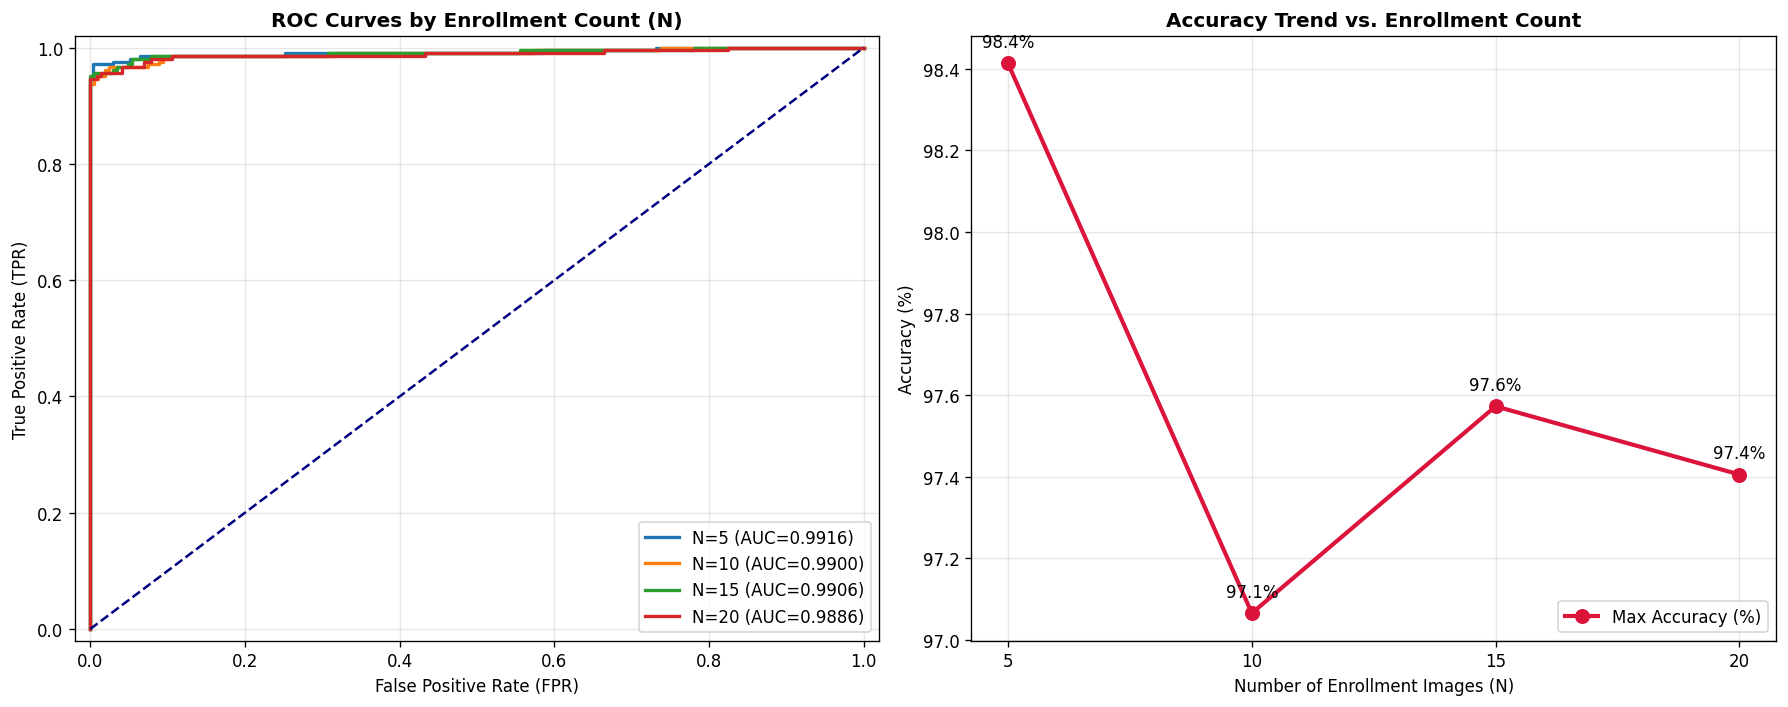

In [ ]:
def run_experiment(subject_embs, n_enrolls_list=[5, 10, 15, 20]):
    """N 장수에 따른 성능 비교 실험을 수행합니다."""
    persons = list(subject_embs.keys())

    if len(persons) < 2:
        print("❌ 비교할 인물이 부족합니다. min_images 조건을 낮춰보세요.")
        return None

    results = {}

    for n in n_enrolls_list:
        print(f"\n🧪 [실험 진행 중] Enrollment N = {n}장 세팅...")
        scores = []
        labels = []

        for i, person in enumerate(persons):
            all_embs = subject_embs[person]

            # 1. N장으로 지문 벡터(Fingerprint) 생성
            enroll_embs = all_embs[:n]
            fingerprint = np.mean(enroll_embs, axis=0)
            fingerprint /= (np.linalg.norm(fingerprint) + 1e-10) # L2 정규화

            # 2. 본인 사진(Positive)과 대조 (n번째 인덱스부터 끝까지)
            query_embs_pos = all_embs[20:] # 공정한 비교를 위해 항상 20번 이후 사진을 테스트 셋으로 고정
            for q_emb in query_embs_pos:
                sim = np.dot(fingerprint, q_emb)
                scores.append(sim)
                labels.append(1)

            # 3. 타인 사진(Negative)과 대조 (무작위로 다른 사람 1명 골라서 대조)
            other_person = random.choice([p for p in persons if p != person])
            query_embs_neg = subject_embs[other_person][20:]
            for q_emb in query_embs_neg:
                sim = np.dot(fingerprint, q_emb)
                scores.append(sim)
                labels.append(0)

        # 성능 평가 (ROC, AUC, 최적 정확도)
        scores = np.array(scores)
        labels = np.array(labels)

        fpr, tpr, thresholds = roc_curve(labels, scores)
        roc_auc = auc(fpr, tpr)

        # 정확도가 가장 높은 지점 찾기
        best_acc = 0
        best_thresh = 0
        for thresh in np.arange(-1.0, 1.0, 0.01):
            preds = (scores >= thresh).astype(int)
            acc = np.mean(preds == labels)
            if acc > best_acc:
                best_acc = acc
                best_thresh = thresh

        results[n] = {
            'fpr': fpr, 'tpr': tpr, 'auc': roc_auc,
            'best_acc': best_acc, 'best_thresh': best_thresh
        }

        print(f"  👉 결과: AUC = {roc_auc:.4f} | 최고 정확도 = {best_acc*100:.2f}% (Thresh: {best_thresh:.3f})")

    return results

def plot_experiment_results(results):
    """실험 결과를 두 개의 그래프로 시각화합니다."""
    ns = list(results.keys())
    aucs = [results[n]['auc'] for n in ns]
    accs = [results[n]['best_acc'] * 100 for n in ns]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=120)

    # [그래프 1] N에 따른 통합 ROC 커브 비교
    for n in ns:
        axes[0].plot(results[n]['fpr'], results[n]['tpr'], lw=2, label=f'N={n} (AUC={results[n]["auc"]:.4f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes[0].set_xlim([-0.02, 1.02])
    axes[0].set_ylim([-0.02, 1.02])
    axes[0].set_xlabel('False Positive Rate (FPR)')
    axes[0].set_ylabel('True Positive Rate (TPR)')
    axes[0].set_title('ROC Curves by Enrollment Count (N)', fontweight='bold')
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    # [그래프 2] N 증가에 따른 정확도(Accuracy) 상승 추이
    axes[1].plot(ns, accs, marker='o', markersize=8, color='crimson', lw=2.5, label='Max Accuracy (%)')
    axes[1].set_xticks(ns)
    axes[1].set_xlabel('Number of Enrollment Images (N)')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy Trend vs. Enrollment Count', fontweight='bold')

    for i, txt in enumerate(accs):
        axes[1].annotate(f"{txt:.1f}%", (ns[i], accs[i]), textcoords="offset points", xytext=(0,10), ha='center')

    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()

    # 구글 드라이브에 저장
    save_path = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/enrollment_N_comparison.png'
    plt.savefig(save_path, bbox_inches='tight')
    print(f"\n💾 비교 결과 그래프가 저장되었습니다: {save_path}")
    plt.show()

if subject_embs:
        # 2. N = 5, 10, 15, 20장 별 성능 평가
        results = run_experiment(subject_embs, n_enrolls_list=[5, 10, 15, 20])

        # 3. 결과 시각화
        if results:
            plot_experiment_results(results)

# threshhold 설정

## i-score & g-score 기반

In [ ]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def find_threshold_by_score_distribution(queries, index, metadata):
    """
    1:N 내부 분포 수집(G-Score, I-Score) 기반 최적 Threshold 계산 및 시각화
    """
    # 1. 쿼리 임베딩 매트릭스 구성 및 L2 정규화
    emb_matrix = np.stack([q[0] for q in queries]).astype('float32')
    faiss.normalize_L2(emb_matrix)

    # 2. 1:N FAISS 검색 (Top-2를 뽑아 본인과 가장 닮은 타인을 동시 수집)
    print("⚡ FAISS 1:N 검색 진행 중 (k=2)...")
    D, I = index.search(emb_matrix, k=2)

    true_names = [q[1] for q in queries]

    g_scores = [] # Genuine Scores (본인 매칭 점수)
    i_scores = [] # Impostor Scores (최악의 타인 매칭 점수)

    # 3. G-Score와 I-Score 분리 수집
    for j in range(len(queries)):
        actual_name = true_names[j]

        top1_id, top1_score = I[j][0], D[j][0]
        top2_id, top2_score = I[j][1], D[j][1]

        top1_name = metadata[top1_id]['name'] if top1_id != -1 else None
        top2_name = metadata[top2_id]['name'] if top2_id != -1 else None

        if top1_name == actual_name:
            # [정상적인 경우] 1등이 본인일 때
            g_scores.append(top1_score)

            # 이때 2등은 무조건 타인이므로, 나를 가장 위협하는 I-Score가 됨
            if top2_name is not None and top2_name != actual_name:
                i_scores.append(top2_score)
        else:
            # [보안 뚫림] 1등부터 엉뚱한 타인일 때
            i_scores.append(top1_score)

            # 본인 점수는 2등으로 밀려났을 수 있으니 확인 후 수집
            if top2_name == actual_name:
                g_scores.append(top2_score)

    print(f"✅ 수집 완료: G-Scores {len(g_scores)}개, I-Scores {len(i_scores)}개")

    # 4. 최적 임계값 수학적 도출 (ROC 기반 Youden's J statistic)
    # G-Score는 1(정답), I-Score는 0(오답)으로 라벨링
    y_true = np.array([1] * len(g_scores) + [0] * len(i_scores))
    y_scores = np.array(g_scores + i_scores)

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    # tpr(본인 수락률)은 높이고, fpr(타인 수락률)은 낮추는 최적의 지점 탐색
    optimal_idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[optimal_idx]

    print("\n" + "="*50)
    print(" 🎯 [점수 분포 기반 분석 결과]")
    print("="*50)
    print(f" 🌟 산출된 최적 Threshold : {best_thresh:.3f}")
    print("="*50)

    # 5. 결과 시각화 (보고서 첨부용 히스토그램)
    plt.figure(figsize=(10, 6), dpi=120)

    # 히스토그램 그리기
    plt.hist(i_scores, bins=40, alpha=0.6, color='crimson', density=True, label='I-Scores (Impostor / 타인)')
    plt.hist(g_scores, bins=40, alpha=0.6, color='royalblue', density=True, label='G-Scores (Genuine / 본인)')

    # 최적 임계값 수직선
    plt.axvline(best_thresh, color='black', linestyle='dashed', linewidth=2.5,
                label=f'Optimal Threshold ({best_thresh:.3f})')

    plt.title('1:N Face Recognition Score Distribution (G-Score vs I-Score)', fontweight='bold')
    plt.xlabel('Cosine Similarity Score')
    plt.ylabel('Density')
    plt.legend(loc='upper center')
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # 그래프 저장 (경로는 환경에 맞게 수정하세요)
    plt.savefig('score_distribution_threshold.png')
    plt.show()

    return best_thresh, g_scores, i_scores

⏳ FAISS DB 및 메타데이터 로딩 중...
✅ DB 로드 완료!
📂 다중 데이터셋 스캔 시작...
🔎 스캔 중: /content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/ms1mv3/MS1MV3_Attack


/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/insightface/recognition/arcface_torch/backbones/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


🔎 스캔 중: /content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/한국 연예인_전처리/한국연예인_Attack
✅ 총 1707장의 통합 쿼리 데이터가 준비되었습니다.

🔍 통합 데이터 기반 최적 임계값 및 G/I-Score 분석 시작...
⚡ FAISS 1:N 검색 진행 중 (k=2)...
✅ 수집 완료: G-Scores 1704개, I-Scores 1707개

 🎯 [점수 분포 기반 분석 결과]
 🌟 산출된 최적 Threshold : 0.443


/tmp/ipykernel_27619/1815761031.py:83: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27619/1815761031.py:83: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27619/1815761031.py:83: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27619/1815761031.py:86: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  plt.savefig('score_distribution_threshold.png')
/tmp/ipykernel_27619/1815761031.py:86: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.savefig('score_distribution_threshold.png')
/tmp/ipykernel_27619/1815761031.py:86: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.savefig('score_distribution_threshold.png')
/usr/local/lib/python3.12/dist-packages/IPython

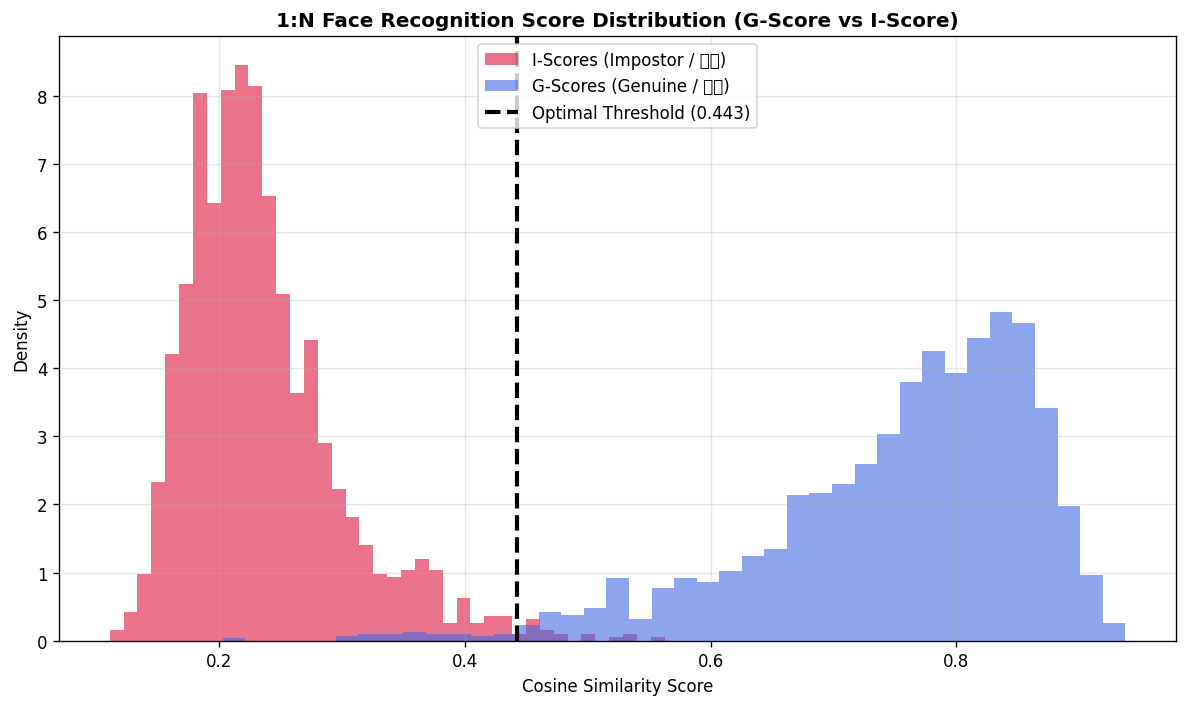


 🚀 통합 시스템 권장 Threshold : 0.443
 ▪ 수집된 G-Scores (본인): 1704개
 ▪ 수집된 I-Scores (타인): 1707개


In [ ]:
import os
import sys
import json
import numpy as np
import faiss

# ====================================================
# 1. 환경 및 경로 설정
# ====================================================
WORKING_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)

from face_embedder import FaceEmbedder

WEIGHT_PATH = os.path.join(WORKING_DIR, 'arc_r18_fp16_backbone.pth')
INDEX_PATH = os.path.join(WORKING_DIR, 'face_database.index')
META_PATH = os.path.join(WORKING_DIR, 'face_metadata.json')

# 🔥 검증에 사용할 다중 데이터셋 경로 리스트
QUERY_DIRS = [
    os.path.join(WORKING_DIR, '데이터셋/ms1mv3/MS1MV3_Attack'),
    os.path.join(WORKING_DIR, '데이터셋/한국 연예인_전처리/한국연예인_Attack')
]

def main():
    # 2. FAISS DB 및 메타데이터 로드
    print("⏳ FAISS DB 및 메타데이터 로딩 중...")
    index = faiss.read_index(INDEX_PATH)
    with open(META_PATH, 'r', encoding='utf-8') as f:
        metadata = {int(k): v for k, v in json.load(f).items()}
    print("✅ DB 로드 완료!")

    # 3. 모든 데이터셋에서 쿼리 이미지 수집
    embedder = FaceEmbedder(WEIGHT_PATH)
    all_queries = []

    print("📂 다중 데이터셋 스캔 시작...")
    for target_dir in QUERY_DIRS:
        if not os.path.exists(target_dir):
            print(f"⚠️ 경로를 찾을 수 없어 건너뜁니다: {target_dir}")
            continue

        print(f"🔎 스캔 중: {target_dir}")
        for root, dirs, files in os.walk(target_dir):
            person_name = os.path.basename(root)
            # 이미지 파일 필터링
            valid_files = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

            if not valid_files: continue

            # 해당 폴더의 이미지 경로 생성
            img_paths = [os.path.join(root, f) for f in valid_files]

            # 배치 단위 임베딩 추출 (추론 속도 최적화)
            embs = embedder.extract_batch(img_paths, batch_size=64).astype('float32')

            for i in range(len(embs)):
                # (임베딩 벡터, 실제 이름) 튜플로 저장
                all_queries.append((embs[i], person_name))

    print(f"✅ 총 {len(all_queries)}장의 통합 쿼리 데이터가 준비되었습니다.")

    # 4. 분석 함수 호출 (앞서 작성한 find_threshold_by_score_distribution 함수)
    if all_queries:
        print("\n🔍 통합 데이터 기반 최적 임계값 및 G/I-Score 분석 시작...")
        best_thresh, g_scores, i_scores = find_threshold_by_score_distribution(all_queries, index, metadata)

        print("\n" + "="*50)
        print(f" 🚀 통합 시스템 권장 Threshold : {best_thresh:.3f}")
        print("="*50)
        print(f" ▪ 수집된 G-Scores (본인): {len(g_scores)}개")
        print(f" ▪ 수집된 I-Scores (타인): {len(i_scores)}개")
        print("="*50)

if __name__ == "__main__":
    main()

In [ ]:
!mv /content/score_distribution_threshold.png '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/'

## Rank-1 기반(폐기)

In [ ]:
def find_best_threshold(queries, index, metadata,
                        threshold_range=np.arange(0.1, 0.9, 0.01)):
    """
    전체 / 그룹별 최적 threshold 탐색 + FAR + FRR 계산
    """
    # 쿼리 전체를 한 번에 FAISS 검색
    emb_matrix = np.stack([q[0] for q in queries]).astype('float32')
    faiss.normalize_L2(emb_matrix)

    D, I = index.search(emb_matrix, k=1)

    true_names = [q[1] for q in queries]
    groups     = [q[2] for q in queries]
    pred_names = [metadata[I[j][0]]['name'] for j in range(len(queries))]
    scores     = D[:, 0]

    # threshold 탐색
    results = []

    for thresh in threshold_range:
        preds   = [pred_names[j] if scores[j] >= thresh else 'unknown'
                   for j in range(len(queries))]
        correct = [preds[j] == true_names[j] for j in range(len(queries))]

        total_acc = np.mean(correct)

        group_acc = {}
        for g in set(groups):
            idx          = [j for j, grp in enumerate(groups) if grp == g]
            group_acc[g] = np.mean([correct[j] for j in idx])

        results.append({
            'threshold': thresh,
            'total_acc': total_acc,
            **{f'{g}_acc': group_acc[g] for g in group_acc}
        })

    # 정확도 동일할 때 threshold 높은 것 선택
    max_acc  = max(r['total_acc'] for r in results)
    best     = max(
        [r for r in results if r['total_acc'] == max_acc],
        key=lambda x: x['threshold']
    )

    best_thresh = best['threshold']

    # ── FAR / FRR 계산 (best threshold 기준)
    # FAR: 다른 사람인데 통과 (False Accept)
    # FRR: 같은 사람인데 거부 (False Reject)

    def compute_far_frr(indices):
        n_genuine  = 0   # 같은 사람 쌍 수
        n_impostor = 0   # 다른 사람 쌍 수
        n_fa       = 0   # False Accept 수
        n_fr       = 0   # False Reject 수

        for j in indices:
            is_same_person = (pred_names[j] == true_names[j] or
                              (scores[j] < best_thresh and
                               metadata[I[j][0]]['name'] == true_names[j]))

            if metadata[I[j][0]]['name'] == true_names[j]:
                # 실제 같은 사람
                n_genuine += 1
                if scores[j] < best_thresh:   # threshold 미달로 거부
                    n_fr += 1
            else:
                # 실제 다른 사람
                n_impostor += 1
                if scores[j] >= best_thresh:  # threshold 통과 → 오인식
                    n_fa += 1

        far = n_fa / n_impostor if n_impostor > 0 else 0.0
        frr = n_fr / n_genuine  if n_genuine  > 0 else 0.0

        return far, frr

    # 전체 FAR / FRR
    all_indices        = list(range(len(queries)))
    total_far, total_frr = compute_far_frr(all_indices)

    # 그룹별 FAR / FRR
    group_far = {}
    group_frr = {}
    for g in set(groups):
        idx            = [j for j, grp in enumerate(groups) if grp == g]
        g_far, g_frr   = compute_far_frr(idx)
        group_far[g]   = g_far
        group_frr[g]   = g_frr

    best['far']       = total_far
    best['frr']       = total_frr
    best['group_far'] = group_far
    best['group_frr'] = group_frr

    return results, best

In [ ]:
results, best = find_best_threshold(queries, index, metadata)

print(f"최적 threshold : {best['threshold']:.2f}")
print(f"전체 Rank-1    : {best['total_acc']:.4f}")
print(f"전체 FAR       : {best['far']:.4f}")
print(f"전체 FRR       : {best['frr']:.4f}")
print()
for g in best['group_far']:
    print(f"[{g}]")
    print(f"  Rank-1 : {best[f'{g}_acc']:.4f}")
    print(f"  FAR    : {best['group_far'][g]:.4f}")
    print(f"  FRR    : {best['group_frr'][g]:.4f}")

최적 threshold : 0.20
전체 Rank-1    : 0.9977
전체 FAR       : 0.7500
전체 FRR       : 0.0000

[western]
  Rank-1 : 1.0000
  FAR    : 0.0000
  FRR    : 0.0000
[korean]
  Rank-1 : 0.9870
  FAR    : 0.7500
  FRR    : 0.0000


In [ ]:
import os
import json
import numpy as np
import faiss
import torch
from pathlib import Path
import sys

# ==========================================
# 1. 경로 설정
# ==========================================
WORKING_DIR  = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'

WORKING_DIR  = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)

from face_embedder import FaceEmbedder

FAISS_INDEX_PATH = os.path.join(WORKING_DIR, 'face_database.index')
META_PATH        = os.path.join(WORKING_DIR, 'face_metadata.json')
WEIGHT_PATH      = os.path.join(WORKING_DIR, 'arc_r18_fp16_backbone.pth')

# attack set 경로
ATTACK_DIRS = {
    'korean':  '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/한국 연예인_전처리/한국연예인_Attack',
    'western': '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/ms1mv3/MS1MV3_Attack',
}


# ==========================================
# 2. FAISS + 메타데이터 로드
# ==========================================
def load_db(index_path, meta_path):
    index    = faiss.read_index(index_path)
    with open(meta_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)
    metadata = {int(k): v for k, v in metadata.items()}
    print(f'✅ DB 로드 완료: {index.ntotal}명')
    return index, metadata


# ==========================================
# 3. attack set 임베딩 수집
# ==========================================
def collect_attack_embeddings(embedder, attack_dirs):
    """
    attack set 전체 이미지 임베딩 추출
    return: [(emb, true_name, group), ...]
    """
    queries = []

    for group, attack_root in attack_dirs.items():
        if not os.path.exists(attack_root):
            print(f'⚠️  [{group}] 폴더 없음: {attack_root}')
            continue

        print(f'\n[{group}] 임베딩 추출 중...')

        for person_dir in sorted(Path(attack_root).iterdir()):
            if not person_dir.is_dir():
                continue

            true_name = person_dir.name
            img_paths = embedder.get_image_paths(str(person_dir))

            if not img_paths:
                continue

            embs = embedder.extract_batch(img_paths, batch_size=64)  # (N, 512)

            for emb in embs:
                queries.append((emb, true_name, group))

        print(f'  → {group} 누적 쿼리: {sum(1 for _, _, g in queries if g == group)}개')

    print(f'\n총 쿼리 수: {len(queries)}개')
    return queries


# ==========================================
# 4. threshold 탐색
# ==========================================
def find_best_threshold(queries, index, metadata,
                        threshold_range=np.arange(0.1, 0.9, 0.01)):
    """
    전체 / 그룹별 최적 threshold 탐색
    """
    # 쿼리 전체를 한 번에 FAISS 검색
    emb_matrix = np.stack([q[0] for q in queries]).astype('float32')
    faiss.normalize_L2(emb_matrix)

    D, I = index.search(emb_matrix, k=1)  # D: 유사도, I: 인덱스
    # D shape: (N, 1), I shape: (N, 1)

    true_names = [q[1] for q in queries]
    groups     = [q[2] for q in queries]
    pred_names = [metadata[I[j][0]]['name'] for j in range(len(queries))]
    scores     = D[:, 0]  # (N,)

    # threshold 탐색
    results = []

    for thresh in threshold_range:
        # threshold 미만이면 unknown 처리
        preds   = [pred_names[j] if scores[j] >= thresh else 'unknown'
                   for j in range(len(queries))]
        correct = [preds[j] == true_names[j] for j in range(len(queries))]

        # 전체 정확도
        total_acc = np.mean(correct)

        # 그룹별 정확도
        group_acc = {}
        for g in set(groups):
            idx       = [j for j, grp in enumerate(groups) if grp == g]
            group_acc[g] = np.mean([correct[j] for j in idx])

        results.append({
            'threshold': thresh,
            'total_acc': total_acc,
            **{f'{g}_acc': group_acc[g] for g in group_acc}
        })

    # 전체 정확도 기준 최적 threshold
    best = max(results, key=lambda x: x['total_acc'])

    return results, best


# ==========================================
# 5. 결과 출력
# ==========================================
def print_results(best, results):
    print('\n' + '='*50)
    print('최적 Threshold 결과')
    print('='*50)
    print(f"threshold : {best['threshold']:.2f}")
    print(f"전체 정확도: {best['total_acc']:.4f}")
    for key, val in best.items():
        if key.endswith('_acc') and key != 'total_acc':
            group = key.replace('_acc', '')
            print(f"{group} 정확도: {val:.4f}")

    # threshold별 변화 출력 (0.05 간격)
    print('\n[threshold별 정확도 변화]')
    print(f"{'threshold':>10} {'전체':>8}", end='')
    groups = [k.replace('_acc', '') for k in best.keys()
              if k.endswith('_acc') and k != 'total_acc']
    for g in groups:
        print(f" {g:>10}", end='')
    print()

    for r in results:
        if round(r['threshold'] * 100) % 5 == 0:  # 0.05 간격만 출력
            print(f"{r['threshold']:>10.2f} {r['total_acc']:>8.4f}", end='')
            for g in groups:
                print(f" {r[f'{g}_acc']:>10.4f}", end='')
            print()


# ==========================================
# 6. threshold 저장
# ==========================================
def save_threshold(best, save_path=None):
    if save_path is None:
        save_path = os.path.join(WORKING_DIR, 'threshold.json')

    data = {
        'threshold': float(best['threshold']),
        'total_acc': float(best['total_acc']),
    }
    with open(save_path, 'w') as f:
        json.dump(data, f, indent=2)
    print(f'\n💾 threshold 저장 완료: {save_path}')


# ==========================================
# 7. 실행
# ==========================================
if __name__ == '__main__':
    # 1. DB 로드
    index, metadata = load_db(FAISS_INDEX_PATH, META_PATH)

    # 2. 모델 로드
    print('⏳ 모델 로딩 중...')
    embedder = FaceEmbedder(weight_path=WEIGHT_PATH)
    print('✅ 모델 로딩 완료!')

    # 3. attack set 임베딩 수집
    queries = collect_attack_embeddings(embedder, ATTACK_DIRS)

    # 4. threshold 탐색
    results, best = find_best_threshold(queries, index, metadata)

    # 5. 결과 출력
    print_results(best, results)

    # 6. 저장
    save_threshold(best)

✅ DB 로드 완료: 70명
⏳ 모델 로딩 중...
✅ 모델 로딩 완료!

[korean] 임베딩 추출 중...
  → korean 누적 쿼리: 307개

[western] 임베딩 추출 중...


KeyboardInterrupt: 

In [ ]:
# 한 번에 원인 파악
print('='*50)
print(f'queries 수: {len(queries)}')
print(f'DB 인물 수: {index.ntotal}')
print()
print('DB 인물명 (상위 5개):')
for i in range(min(5, len(metadata))):
    print(f'  {i}: {metadata[i]}')
print()
print('attack 인물명 (상위 5개):')
for emb, name, group in queries[:5]:
    print(f'  {group}: {name}')
print()

# 실제 검색 테스트
emb = queries[0][0].astype('float32').reshape(1, -1)
faiss.normalize_L2(emb)
D, I = index.search(emb, k=1)
print(f'검색 테스트:')
print(f'  유사도: {D[0][0]:.4f}')
print(f'  예측:   {metadata[I[0][0]]}')
print(f'  정답:   {queries[0][1]}')
print(f'  일치:   {metadata[I[0][0]] == queries[0][1]}')

queries 수: 1707
DB 인물 수: 70

DB 인물명 (상위 5개):
  0: {'name': '김고은', 'group': 'korean'}
  1: {'name': '나재민', 'group': 'korean'}
  2: {'name': '남궁민', 'group': 'korean'}
  3: {'name': '류진', 'group': 'korean'}
  4: {'name': '마동석', 'group': 'korean'}

attack 인물명 (상위 5개):
  korean: 김고은
  korean: 김고은
  korean: 김고은
  korean: 김고은
  korean: 김고은

검색 테스트:
  유사도: 0.6012
  예측:   {'name': '김고은', 'group': 'korean'}
  정답:   김고은
  일치:   False


## 1:1 정확도 기반(폐기)

### match, mismatch set 추출

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 구글 드라이브에 있는 '데이터셋' 폴더 전체를 코랩의 고속 로컬 스토리지(/content/dataset/)로 복사
!cp -r "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/ms1mv3/MS1MV3_Attack" "/content/dataset/ms1mv3"
!cp -r "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/ms1mv3/MS1MV3_Enrollment" "/content/dataset/ms1mv3"
!cp -r "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/한국 연예인_전처리/한국연예인_Attack" "/content/dataset/한국 연예인_전처리"
!cp -r "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/한국 연예인_전처리/한국연예인_Enrollment" "/content/dataset/한국 연예인_전처리"

print("⚡ 초고속 가상 SSD로 복사가 완료되었습니다!")

^C
^C
^C
⚡ 초고속 가상 SSD로 복사가 완료되었습니다!


In [ ]:
import os
import random
import numpy as np

def generate_custom_pairs(dataset_base_dir, max_pairs_per_group=1500):
    """
    디렉터리 구조를 분석하여 동일인(Match)과 타인(Mismatch) 이미지 쌍을 자동 생성합니다.

    Args:
        dataset_base_dir (str): '데이터셋' 최상위 루트 폴더 경로
        max_pairs_per_group (int): 생성할 Match/Mismatch의 최대 목표 개수 (각각)

    Returns:
        tuple: (이미지1 리스트, 이미지2 리스트, 라벨 배열)
    """

    # 1. 탐색할 두 하위 디렉터리 경로 설정
    enroll_paths = [
        os.path.join(dataset_base_dir, 'ms1mv3', 'MS1MV3_AttackSet'),        # Western
        os.path.join(dataset_base_dir, '한국 연예인_전처리', '한국연예인_AttackSet') # Korean
    ]

    all_persons_dict = {}

    print("⏳ 데이터셋 디렉터리를 스캔 중입니다...")

    # 2. 모든 폴더와 그 안의 이미지 경로들을 딕셔너리로 수집
    for base_dir in enroll_paths:
        if not os.path.exists(base_dir):
            print(f"⚠️ 폴더를 찾을 수 없어 건너뜁니다: {base_dir}")
            continue

        celebrities = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

        for name in celebrities:
            person_dir = os.path.join(base_dir, name)
            # 이미지 확장자 필터링 (.jpg, .jpeg, .png 등)
            images = [
                os.path.join(person_dir, f) for f in os.listdir(person_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]

            # 최소 2장 이상의 사진이 있는 인물만 수집 (Match 쌍을 만들기 위해)
            if len(images) >= 2:
                all_persons_dict[name] = images

    persons_list = list(all_persons_dict.keys())

    if len(persons_list) < 2:
        print("❌ 테스트 셋을 만들기 위한 충분한 인물/이미지가 없습니다.")
        return [], [], np.array([])

    print(f"✅ 총 {len(persons_list)}명의 인물로부터 데이터를 수집했습니다.")

    pairs = []

    # ---------------------------------------------------------
    # 3. Match Pairs (동일인 쌍, Label=1) 생성
    # ---------------------------------------------------------
    match_count = 0
    # 모든 사람을 한 번씩 돌면서 쌍을 만듭니다.
    for person, images in all_persons_dict.items():
        if match_count >= max_pairs_per_group:
            break

        # 해당 인물의 사진 중 무작위 2장 선택
        img1, img2 = random.sample(images, 2)
        pairs.append((img1, img2, 1))
        match_count += 1

    # 목표치에 도달하지 못했다면 무작위로 인물을 뽑아 추가로 만듭니다.
    while match_count < max_pairs_per_group:
        person = random.choice(persons_list)
        img1, img2 = random.sample(all_persons_dict[person], 2)
        pairs.append((img1, img2, 1))
        match_count += 1

    # ---------------------------------------------------------
    # 4. Mismatch Pairs (타인 쌍, Label=0) 생성
    # ---------------------------------------------------------
    mismatch_count = 0
    while mismatch_count < max_pairs_per_group:
        # 무작위로 서로 다른 두 명의 인물 선택
        person1, person2 = random.sample(persons_list, 2)

        # 각 인물에게서 사진 1장씩 선택
        img1 = random.choice(all_persons_dict[person1])
        img2 = random.choice(all_persons_dict[person2])

        pairs.append((img1, img2, 0))
        mismatch_count += 1

    # 5. 생성된 쌍들을 랜덤하게 섞기 (학습/평가 시 특정 라벨이 몰리지 않도록)
    random.shuffle(pairs)

    # 6. LFW 코드와 동일한 포맷으로 언패킹
    imgs1 = [p[0] for p in pairs]
    imgs2 = [p[1] for p in pairs]
    labels = np.array([p[2] for p in pairs])

    same = sum(labels == 1)
    diff = sum(labels == 0)

    print("==================================================")
    print(f"🎉 총 테스트 쌍 생성 완료: {len(pairs)}쌍")
    print(f"   - Match(동일인): {same}쌍")
    print(f"   - Mismatch(타인): {diff}쌍")
    print("==================================================")

    return imgs1, imgs2, labels

# --- 실제 실행 예시 ---
# 구글 드라이브 내 데이터셋 최상위 폴더 경로를 입력합니다.
BASE_DIR = '/content/dataset'

# 함수 실행 (각각 500쌍씩 총 1000쌍의 테스트 셋 생성)
imgs1, imgs2, labels = generate_custom_pairs(BASE_DIR, max_pairs_per_group=1500)

# (선택) 제대로 만들어졌는지 앞의 3개만 확인
print("\n[샘플 확인]")
for i in range(3):
    print(f"쌍 {i+1} (정답: {labels[i]}): \n  1: {os.path.basename(imgs1[i])}\n  2: {os.path.basename(imgs2[i])}")

⏳ 데이터셋 디렉터리를 스캔 중입니다...
✅ 총 70명의 인물로부터 데이터를 수집했습니다.
🎉 총 테스트 쌍 생성 완료: 3000쌍
   - Match(동일인): 1500쌍
   - Mismatch(타인): 1500쌍

[샘플 확인]
쌍 1 (정답: 1): 
  1: 장원영_정면_23_face_0.jpg
  2: 장원영_옆모습_2_face_0.jpg
쌍 2 (정답: 1): 
  1: 현아_정면_39_face_0.jpg
  2: 현아_정면_5_face_0.jpg
쌍 3 (정답: 0): 
  1: 박보검_옆모습_12_face_0.jpg
  2: 0003.jpg


### threshhold 탐색

In [ ]:
# Attack으로만 판단
from face_embedder import FaceEmbedder

def evaluate(model, imgs1, imgs2, labels):
    print('  임베딩 추출 중...')
    embs1 = model.extract_batch(imgs1, batch_size=64) #첫번째 이미지를 임베딩 추출 ->(2200,512)
    embs2 = model.extract_batch(imgs2, batch_size=64) #두번째 이미지를 임베딩 추출 ->(2200,512)

    scores = np.sum(embs1 * embs2, axis=1)
    #두 임베딩의 코사인 유사도를 계산함
    #L2 정규화된 벡터끼리 곱하면 코사인 유사도가 됨
    #결과: (2200, )배열이되고 각 쌍의 유사도 점수를 의미함
      #유사도가 높으면(1에 가까우면) 같은사람인 것임

    best_acc, best_thresh = 0, 0

    for thresh in np.arange(-1.0, 1.0, 0.01):
        preds = (scores >= thresh).astype(int)
        acc = np.mean(preds == labels)

        if acc > best_acc: #더 높은 정확도가 나오면 업데이트
            best_acc, best_thresh = acc, thresh

    return best_acc, best_thresh, scores
    #최고 정확도, 그때의 threshold

filename = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/arc_r18_fp16_backbone.pth'
print(f'\n{"="*50}') #구분선
print(f'{filename}') #평가 중인 모델명 출력
print(f'{"="*50}') #구분선

embedder = FaceEmbedder(filename) #가중치 파일 로드

acc, thresh, scores = evaluate(embedder, imgs1, imgs2, labels)

print(f'  정확도: {acc*100:.2f}%')
print(f'  최적 threshold: {thresh:.3f}')




/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/arc_r18_fp16_backbone.pth
  임베딩 추출 중...


/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/insightface/recognition/arcface_torch/backbones/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


  정확도: 98.80%
  최적 threshold: 0.200


/tmp/ipykernel_6786/2485128476.py:42: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbox_inches='tight')
/tmp/ipykernel_6786/2485128476.py:42: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbox_inches='tight')
/tmp/ipykernel_6786/2485128476.py:42: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbox_inches='tight')
/tmp/ipykernel_6786/2485128476.py:42: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbox_inches='tight')
/tmp/ipykernel_6786/2485128476.py:42: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbox_inches='tight')
/tmp/ipykernel_6786/2485128476.py:42: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbo

💾 ROC 커브 그래프가 성공적으로 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/arc_r18_roc_curve.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

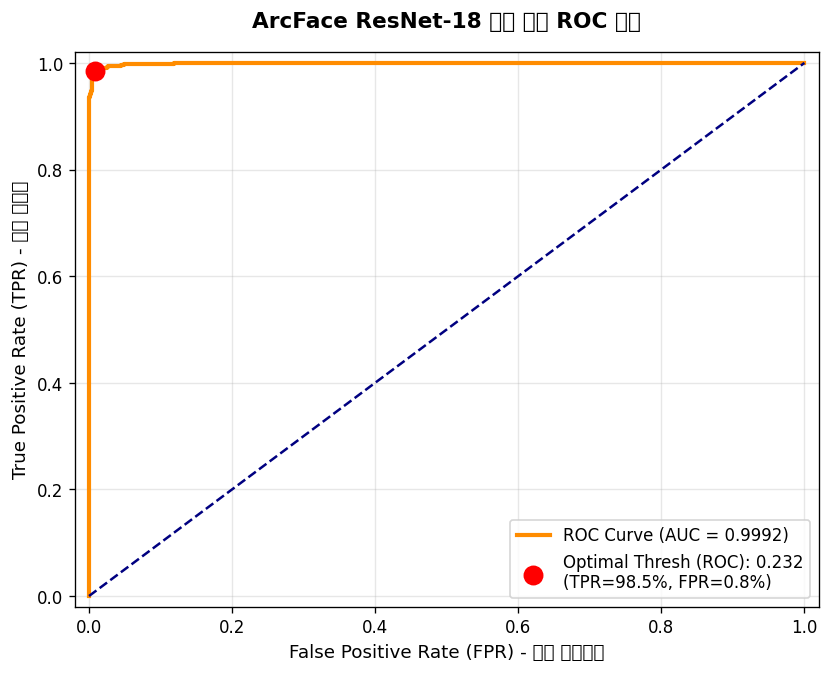

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. scikit-learn의 roc_curve 함수를 이용해 좌표값 계산
# evaluate 함수 연산에 쓰였던 'scores'와 'labels' 배열을 그대로 활용합니다.
fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

# 2. Youden's J-statistic 수식으로 최적의 임계값 좌표 찾기
# (본인 인식률 - 타인 오인식률이 가장 극대화되는 지점)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

# 3. 그래프 시각화 세팅
plt.figure(figsize=(8, 6), dpi=120)

# ROC 곡선 플롯 (주황색 실선)
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')

# 무작위 분류 기준선 (파란 대각 점선)
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')

# 방금 코드에서 구한 최적의 임계값(0.230) 위치를 빨간 점으로 그래프에 마킹!
# (수학적 밸런스 지점과 실제 구하신 0.230이 어떻게 매칭되는지 눈으로 확인할 수 있습니다.)
plt.scatter(optimal_fpr, optimal_tpr, color='red', s=120, zorder=5,
            label=f'Optimal Thresh (ROC): {optimal_threshold:.3f}\n(TPR={optimal_tpr*100:.1f}%, FPR={optimal_fpr*100:.1f}%)')

# 그래프 라벨 및 격자 설정
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.title('ArcFace ResNet-18 evaluation ROC curve', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)

# 4. 이미지 파일로 구글 드라이브 프로젝트 폴더에 자동 저장
save_path = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/arc_r18_roc_curve.png'
plt.savefig(save_path, bbox_inches='tight')
print(f"💾 ROC 커브 그래프가 성공적으로 저장되었습니다: {save_path}")

plt.show()

In [ ]:
# Enrollment 데이터 포함...
from face_embedder import FaceEmbedder

def evaluate(model, imgs1, imgs2, labels):
    print('  임베딩 추출 중...')
    embs1 = model.extract_batch(imgs1, batch_size=64) #첫번째 이미지를 임베딩 추출 ->(2200,512)
    embs2 = model.extract_batch(imgs2, batch_size=64) #두번째 이미지를 임베딩 추출 ->(2200,512)

    scores = np.sum(embs1 * embs2, axis=1)
    #두 임베딩의 코사인 유사도를 계산함
    #L2 정규화된 벡터끼리 곱하면 코사인 유사도가 됨
    #결과: (2200, )배열이되고 각 쌍의 유사도 점수를 의미함
      #유사도가 높으면(1에 가까우면) 같은사람인 것임

    best_acc, best_thresh = 0, 0

    for thresh in np.arange(-1.0, 1.0, 0.01):
        preds = (scores >= thresh).astype(int)
        acc = np.mean(preds == labels)

        if acc > best_acc: #더 높은 정확도가 나오면 업데이트
            best_acc, best_thresh = acc, thresh

    return best_acc, best_thresh
    #최고 정확도, 그때의 threshold

filename = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/arc_r18_fp16_backbone.pth'
print(f'\n{"="*50}') #구분선
print(f'{filename}') #평가 중인 모델명 출력
print(f'{"="*50}') #구분선

embedder = FaceEmbedder(filename) #가중치 파일 로드

acc, thresh = evaluate(embedder, imgs1, imgs2, labels)

print(f'  정확도: {acc*100:.2f}%')
print(f'  최적 threshold: {thresh:.3f}')




/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/arc_r18_fp16_backbone.pth
  임베딩 추출 중...


/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/insightface/recognition/arcface_torch/backbones/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


  정확도: 98.80%
  최적 threshold: 0.230


In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. 작업 디렉토리 및 face_embedder 설정
WORKING_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)

from face_embedder import FaceEmbedder

# 가중치 경로 (1:1 대조에서 성공했던 cos_r100 모델 사용!)
WEIGHT_PATH = os.path.join(WORKING_DIR, 'cos_r100_fp16_backbone.pth')


def load_test_pairs():
    """
    [가이드] 테스트할 이미지 쌍(Pairs) 목록을 생성하는 함수입니다.
    실제 프로젝트의 데이터셋 구조에 맞게 이 부분을 수정하셔야 합니다.
    """
    # 임시 예시 데이터셋 구조 (실제 경로에 맞게 파일명들을 변경해 주세요)
    # 구조: (이미지1 경로, 이미지2 경로, 동일인 여부[동일인: 1, 타인: 0])
    base_korean_path = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/한국 연예인_전처리'

    test_pairs = [
        # == 동일인 쌍 (Positive Pairs) ==
        (
            f"{base_korean_path}/한국연예인_Enrollment/김고은/김고은_정면_1.jpg",
            f"{base_korean_path}/한국연예인_AttackSet/김고은/김고은_옆모습_41_face_0.jpg",
            1
        ),
        # ... 여기에 더 많은 동일인 이미지 쌍 추가 ...

        # == 타인 쌍 (Negative Pairs) ==
        (
            f"{base_korean_path}/한국연예인_Enrollment/김고은/김고은_정면_1.jpg",
            f"{base_korean_path}/한국연예인_Enrollment/나재민/나재민_정면_1.jpg", # 예시 경로
            0
        ),
        # ... 여기에 더 많은 타인 이미지 쌍 추가 ...
    ]

    return test_pairs


def get_similarities_and_labels(embedder, test_pairs):
    """테스트 쌍들로부터 임베딩을 추출하고 코사인 유사도를 계산합니다."""
    similarities = []
    labels = []

    print(f"⚡ 총 {len(test_pairs)}개의 테스트 이미지 쌍 분석 시작...")

    for idx, (img1_path, img2_path, label) in enumerate(test_pairs):
        if not os.path.exists(img1_path) or not os.path.exists(img2_path):
            print(f"⚠️ [건너뜀] 파일을 찾을 수 없습니다: {img1_path} 또는 {img2_path}")
            continue

        # 임베딩 추출 (float32 변환)
        emb1 = embedder.extract_batch([img1_path], batch_size=1).astype('float32')
        emb2 = embedder.extract_batch([img2_path], batch_size=1).astype('float32')

        if emb1.shape[0] == 0 or emb2.shape[0] == 0:
            continue

        # ⚠️ 수식 오차를 방지하기 위해 추출한 임베딩 벡터 정규화
        emb1 /= (np.linalg.norm(emb1) + 1e-10)
        emb2 /= (np.linalg.norm(emb2) + 1e-10)

        # 코사인 유사도 계산 (두 벡터의 내적)
        similarity = float(np.dot(emb1[0], emb2[0]))

        similarities.append(similarity)
        labels.append(label)

        if (idx + 1) % 10 == 0 or (idx + 1) == len(test_pairs):
            print(f"   [진행 상황] {idx + 1}/{len(test_pairs)} 완료...")

    return np.array(similarities), np.array(labels)


def analyze_and_plot_roc(similarities, labels, save_plot_path=None):
    """ROC 커브를 분석하고 최적의 Threshold를 도출합니다."""
    # 1. ROC 계산
    fpr, tpr, thresholds = roc_curve(labels, similarities)
    roc_auc = auc(fpr, tpr)

    # 2. 기준별 최적 Threshold 도출
    # 기준 A: Youden's J-statistic (정확도의 균형이 최고인 지점)
    youdens_j = tpr - fpr
    best_idx_j = np.argmax(youdens_j)
    thresh_j = thresholds[best_idx_j]

    # 기준 B: High Security (타인 오인식율(FPR)을 1% 이하로 극단 통제할 때)
    target_fpr = 0.01
    best_idx_sec = np.where(fpr <= target_fpr)[0][-1]
    thresh_sec = thresholds[best_idx_sec]

    # 3. 결과 출력
    print("\n" + "="*50)
    print("🎯 [최적 Threshold 분석 보고서]")
    print("="*50)
    print(f"📈 AUC (Area Under Curve): {roc_auc:.4f}")
    print(f"   (1.0에 가까울수록 성능이 완벽함을 뜻함)")

    print(f"\n⚖️ [기준 1] Youden's Index (정확도 균형 중심)")
    print(f"   👉 권장 임계값 (Threshold): {thresh_j:.4f}")
    print(f"   - 진짜 본인을 맞춘 비율 (TPR): {tpr[best_idx_j]*100:.2f}%")
    print(f"   - 타인을 통과시켜준 비율 (FPR): {fpr[best_idx_j]*100:.2f}%")

    print(f"\n🛡️ [기준 2] High Security (보안 강화 중심 - FPR 1% 제한)")
    print(f"   👉 권장 임계값 (Threshold): {thresh_sec:.4f}")
    print(f"   - 진짜 본인을 맞춘 비율 (TPR): {tpr[best_idx_sec]*100:.2f}%")
    print(f"   - 타인을 통과시켜준 비율 (FPR): {fpr[best_idx_sec]*100:.2f}%")
    print("="*50 + "\n")

    # 4. 시각화 그래프 그리기
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (Area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')

    # 그래프 위에 최적 지점 마킹하기
    plt.scatter(fpr[best_idx_j], tpr[best_idx_j], color='red', s=100, zorder=5,
                label=f"Best Balance (Thresh: {thresh_j:.3f})")
    plt.scatter(fpr[best_idx_sec], tpr[best_idx_sec], color='green', s=100, zorder=5,
                label=f"High Security (Thresh: {thresh_sec:.3f})")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR) - 타인 수락율')
    plt.ylabel('True Positive Rate (TPR) - 본인 인식률')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    if save_plot_path:
        plt.savefig(save_plot_path, dpi=300, bbox_inches='tight')
        print(f"💾 ROC 분석 차트 저장 완료: {save_plot_path}")

    plt.show()


# ----------------------------------------------------
# 메인 실행 부
# ----------------------------------------------------
if __name__ == "__main__":
    # 1. 모델 로드
    print("⏳ 얼굴 인식 가중치 모델 로딩 중...")
    embedder = FaceEmbedder(weight_path=WEIGHT_PATH)
    print("✅ 모델 준비 완료!")

    # 2. 대조군 이미지 리스트 빌드
    test_pairs = load_test_pairs()

    if len(test_pairs) == 0:
        print("❌ 테스트 데이터셋 쌍이 정의되지 않았습니다. load_test_pairs() 함수를 수정해주세요.")
    else:
        # 3. 유사도 및 라벨 뽑기
        similarities, labels = get_similarities_and_labels(embedder, test_pairs)

        # 4. 최적 임계값 도출 및 차트 생성
        PLOT_PATH = os.path.join(WORKING_DIR, 'roc_curve_result.png')
        analyze_and_plot_roc(similarities, labels, save_plot_path=PLOT_PATH)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def find_optimal_threshold(similarities, labels, save_plot_path=None):
    """
    코사인 유사도와 실제 라벨을 기반으로 최적의 임계값(Threshold)을 찾아내고 ROC 커브를 그립니다.

    Args:
        similarities (np.ndarray): 각 이미지 쌍의 코사인 유사도 배열 (범위: -1.0 ~ 1.0)
        labels (np.ndarray): 실제 정답 배열 (동일인: 1, 타인: 0)
        save_plot_path (str, optional): ROC 커브 차트를 저장할 경로

    Returns:
        dict: 최적의 Threshold 정보들을 담은 딕셔너리
    """
    # 1. ROC 커브 계산 (FPR: 위양성률, TPR: 재현율, thresholds: 임계값들)
    # y_true(labels)와 y_score(similarities)를 전달합니다.
    fpr, tpr, thresholds = roc_curve(labels, similarities)
    roc_auc = auc(fpr, tpr) # ROC 곡선 아래 면적 계산 (1.0에 가까울수록 모델 성능 우수)

    # 2. 최적의 임계값 도출 기준 계산
    # 기준 A: Youden's J-statistic (TPR - FPR이 최대가 되는 지점, 즉 전체 밸런스가 가장 좋은 곳)
    youdens_j = tpr - fpr
    best_idx_j = np.argmax(youdens_j)
    threshold_j = thresholds[best_idx_j]

    # 기준 B: 보안 강화 기준 (FPR이 0.1% 이하, 혹은 1% 이하로 매우 극단적으로 낮을 때의 기준)
    # 실무 보안 장비에서는 타인이 뚫릴 확률(FPR)을 아주 강하게 통제합니다.
    target_fpr = 0.01  # 타인을 본인으로 잘못 인식할 확률을 1% 이하로 제어
    best_idx_sec = np.where(fpr <= target_fpr)[0][-1]
    threshold_sec = thresholds[best_idx_sec]

    # 3. 결과 출력
    print("==================================================")
    print("🎯 [임계값 최적화 결과 분석 수치]")
    print("==================================================")
    print(f"📈 AUC (Area Under Curve): {roc_auc:.4f}")
    print("\n[⚖️ 기준 1: Youden's Index (정확도 균형 중심)]")
    print(f"   - 최적 Threshold: {threshold_j:.4f}")
    print(f"   - 본인 인식 성공률 (TPR): {tpr[best_idx_j]*100:.2f}%")
    print(f"   - 타인 오인식 확률 (FPR): {fpr[best_idx_j]*100:.2f}%")

    print(f"\n[🛡️ 기준 2: High Security (보안 통제 중심, FPR <= {target_fpr*100}%)]")
    print(f"   - 최적 Threshold: {threshold_sec:.4f}")
    print(f"   - 본인 인식 성공률 (TPR): {tpr[best_idx_sec]*100:.2f}%")
    print(f"   - 타인 오인식 확률 (FPR): {fpr[best_idx_sec]*100:.2f}%")
    print("==================================================")

    # 4. ROC 커브 차트 그리기 및 저장
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 랜덤 분류 기준선

    # 그래프에 최적 임계값 포인트 점 찍기
    plt.scatter(fpr[best_idx_j], tpr[best_idx_j], color='red', s=100, zorder=5,
                label=f"Best (Youden): Thresh={threshold_j:.3f}")
    plt.scatter(fpr[best_idx_sec], tpr[best_idx_sec], color='green', s=100, zorder=5,
                label=f"Security (FPR<1%): Thresh={threshold_sec:.3f}")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR) - 타인 수락율')
    plt.ylabel('True Positive Rate (TPR) - 본인 인식률')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    if save_plot_path:
        plt.savefig(save_plot_path, dpi=300, bbox_inches='tight')
        print(f"💾 ROC 차트가 저장되었습니다: {save_plot_path}")

    plt.show()

    return {
        'auc': roc_auc,
        'best_threshold_balance': threshold_j,
        'best_threshold_security': threshold_sec
    }

# numpy DB(폐기)

In [ ]:
import os
import json
import numpy as np
from collections import defaultdict
from face_embedder import FaceEmbedder

def build_numpy_database(enrollment_paths, weight_path, npy_save_path, meta_save_path, batch_size=64):
    """
    지정된 Enrollment 경로들로부터 임베딩을 추출하고 NumPy 배열 기반의 DB를 구축합니다.
    """
    print("[1/4] FaceEmbedder 초기화 중...")
    try:
        embedder = FaceEmbedder(weight_path=weight_path)
    except Exception as e:
        print(f"오류: FaceEmbedder 초기화 실패 - {e}")
        return

    # 2. 데이터셋 파싱 (Enrollment 폴더만 타겟팅)
    print("[2/4] Enrollment 디렉토리 스캔 중...")
    person_images = defaultdict(list)

    for group, group_dir in enrollment_paths.items():
        if not os.path.isdir(group_dir):
            print(f"  -> ⚠️ 경고: '{group_dir}' 경로를 찾을 수 없습니다. 건너뜁니다.")
            continue

        for name in os.listdir(group_dir):
            person_dir = os.path.join(group_dir, name)
            if not os.path.isdir(person_dir):
                continue

            img_paths = embedder.get_image_paths(person_dir)
            if img_paths:
                person_images[(group, name)].extend(img_paths)

    if not person_images:
        print("등록할 이미지를 찾을 수 없습니다. 폴더 경로를 다시 확인해주세요.")
        return

    # 3. 임베딩 추출 및 지문 벡터(평균) 생성
    print(f"\n[3/4] 총 {len(person_images)}명의 인물 데이터 처리 및 임베딩 추출 시작...")

    fingerprints = []
    person_meta = {}  # db_index -> metadata

    for idx, ((group, name), img_paths) in enumerate(person_images.items()):
        print(f"  -> [{idx+1}/{len(person_images)}] {name} ({group}) - 이미지 {len(img_paths)}장 처리 중")

        # Batch 단위로 임베딩 추출
        embs = embedder.extract_batch(img_paths, batch_size=batch_size)

        if embs.shape[0] == 0:
            print(f"     ⚠️ {name}의 임베딩 추출 실패. 건너뜁니다.")
            continue

        # 인물별 평균 벡터 계산 (1:N 매칭을 위한 기준 지문 벡터)
        mean_emb = np.mean(embs, axis=0)

        # [핵심] 코사인 유사도 연산을 위해 평균 벡터를 L2 정규화
        norm = np.linalg.norm(mean_emb)
        if norm > 0:
            mean_emb = mean_emb / norm

        fingerprints.append(mean_emb)
        person_meta[str(idx)] = {'name': name, 'group': group}

    if not fingerprints:
        print("\n생성된 지문 벡터가 없습니다.")
        return

    # 4. NumPy 배열(.npy) 및 메타데이터 저장
    print("\n[4/4] NumPy 배열 및 메타데이터 저장 중...")

    # 리스트를 2D NumPy 배열로 변환 (형태: [인물 수, 512])
    fingerprints_np = np.vstack(fingerprints).astype(np.float32)

    # .npy 파일로 저장
    np.save(npy_save_path, fingerprints_np)

    # 메타데이터 저장
    with open(meta_save_path, 'w', encoding='utf-8') as f:
        json.dump(person_meta, f, ensure_ascii=False, indent=4)

    print(f"\n✅ NumPy 데이터베이스 구축 완료!")
    print(f"   - 등록된 인물 수: {fingerprints_np.shape[0]}명")
    print(f"   - DB 배열 파일: {npy_save_path} (Shape: {fingerprints_np.shape})")
    print(f"   - 메타데이터 파일: {meta_save_path}")


if __name__ == "__main__":
    # 사용자님의 실제 Colab 환경 드라이브 경로
    BASE_DATASET_DIR = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋"

    # Enrollment 폴더만 명시적으로 매핑
    ENROLLMENT_PATHS = {
        'western': os.path.join(BASE_DATASET_DIR, 'ms1mv3', 'MS1MV3_Enrollment'),
        'korean': os.path.join(BASE_DATASET_DIR, '한국 연예인_전처리', '한국연예인_Enrollment')
    }

    # 가중치 경로 (현재 환경에 맞게 유지)
    WEIGHT_PATH = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/arc_r18_fp16_backbone.pth"

    # 출력 파일 이름 변경 (.bin -> .npy)
    NPY_SAVE_PATH = "db_embeddings.npy"
    META_SAVE_PATH = "db_meta.json"

    build_numpy_database(
        enrollment_paths=ENROLLMENT_PATHS,
        weight_path=WEIGHT_PATH,
        npy_save_path=NPY_SAVE_PATH,
        meta_save_path=META_SAVE_PATH,
        batch_size=64
    )

[1/4] FaceEmbedder 초기화 중...
[2/4] Enrollment 디렉토리 스캔 중...

[3/4] 총 70명의 인물 데이터 처리 및 임베딩 추출 시작...
  -> [1/70] identity_0020209 (western) - 이미지 15장 처리 중
  -> [2/70] identity_0003968 (western) - 이미지 15장 처리 중
  -> [3/70] identity_0049006 (western) - 이미지 15장 처리 중
  -> [4/70] identity_0043617 (western) - 이미지 15장 처리 중
  -> [5/70] identity_0039519 (western) - 이미지 15장 처리 중
  -> [6/70] identity_0025069 (western) - 이미지 15장 처리 중
  -> [7/70] identity_0018643 (western) - 이미지 15장 처리 중
  -> [8/70] identity_0016492 (western) - 이미지 15장 처리 중
  -> [9/70] identity_0074678 (western) - 이미지 15장 처리 중
  -> [10/70] identity_0005757 (western) - 이미지 15장 처리 중
  -> [11/70] identity_0005354 (western) - 이미지 15장 처리 중
  -> [12/70] identity_0017348 (western) - 이미지 15장 처리 중
  -> [13/70] identity_0038598 (western) - 이미지 15장 처리 중
  -> [14/70] identity_0041362 (western) - 이미지 15장 처리 중
  -> [15/70] identity_0088874 (western) - 이미지 15장 처리 중
  -> [16/70] identity_0004627 (western) - 이미지 15장 처리 중
  -> [17/70] identity_0035240 (w

In [ ]:
import os
import json
import numpy as np
from face_embedder import FaceEmbedder

def load_database(npy_path, meta_path):
    """저장된 NumPy 배열과 메타데이터를 불러옵니다."""
    print("[*] 데이터베이스 로드 중...")
    db_embeddings = np.load(npy_path)

    with open(meta_path, 'r', encoding='utf-8') as f:
        db_meta = json.load(f)

    print(f"  -> DB 로드 완료: 총 {db_embeddings.shape[0]}명")
    return db_embeddings, db_meta

def verify_face(embedder, img_path, db_embeddings, db_meta, threshold=0.5):
    """
    1장의 이미지를 입력받아 DB 전체와 비교하고 매칭 결과를 반환합니다.
    - threshold: ArcFace 모델의 경우 보통 0.4 ~ 0.6 사이를 기준으로 잡습니다.
    """
    # 1. 공격 대상(Target) 이미지 임베딩 추출
    embs = embedder.extract_batch([img_path], batch_size=1)

    if embs.shape[0] == 0:
        return {"status": "error", "message": "얼굴을 찾을 수 없거나 임베딩 추출 실패"}

    query_emb = embs[0]

    # 2. 쿼리 벡터 L2 정규화 (필수)
    norm = np.linalg.norm(query_emb)
    if norm > 0:
        query_emb = query_emb / norm

    # 3. 코사인 유사도 연산 (행렬 곱)
    # query_emb.shape = (512,), db_embeddings.T.shape = (512, N)
    # similarities.shape = (N,) -> 각 인물별 유사도 점수 배열
    similarities = np.dot(query_emb, db_embeddings.T)

    # 4. 가장 유사도가 높은 인물 찾기
    best_match_idx = np.argmax(similarities)
    best_score = similarities[best_match_idx]

    # 메타데이터에서 해당 인물 정보 가져오기 (db_meta의 키는 문자열 처리되어 있음)
    matched_person = db_meta[str(best_match_idx)]

    # 5. 임계값(Threshold) 통과 여부 판별
    is_success = best_score >= threshold

    return {
        "status": "success",
        "is_authenticated": is_success,
        "best_score": best_score,
        "matched_name": matched_person['name'],
        "matched_group": matched_person['group']
    }

if __name__ == "__main__":
    # --- 1. 환경 설정 ---
    WEIGHT_PATH = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/arc_r18_fp16_backbone.pth"
    NPY_DB_PATH = "db_embeddings.npy"
    META_DB_PATH = "db_meta.json"

    # 테스트할 AttackSet 이미지 경로 (사용자님 데이터셋 기준 예시)
    TEST_IMAGE_PATH = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/한국 연예인_전처리/한국연예인_AttackSet/카리나/카리나_정면_13_face_0.jpg"

    # --- 2. 초기화 및 로드 ---
    embedder = FaceEmbedder(weight_path=WEIGHT_PATH)
    db_embeddings, db_meta = load_database(NPY_DB_PATH, META_DB_PATH)

    # --- 3. 단일 이미지 모의 인증 테스트 ---
    print(f"\n[*] 타겟 이미지 분석 중: {TEST_IMAGE_PATH}")

    # 임계값(Threshold) 설정: 이 점수를 넘어야 '본인'으로 인식 (보통 보수적인 시스템은 0.6)
    THRESHOLD = 0.5

    result = verify_face(embedder, TEST_IMAGE_PATH, db_embeddings, db_meta, threshold=THRESHOLD)

    # --- 4. 결과 출력 ---
    if result["status"] == "success":
        print("\n=== 얼굴 인식 시뮬레이션 결과 ===")
        print(f"- 매칭된 DB 인물 : {result['matched_name']} ({result['matched_group']})")
        print(f"- 유사도 점수    : {result['best_score']:.4f}")
        print(f"- 시스템 임계값  : {THRESHOLD}")

        if result["is_authenticated"]:
            print(">> 🟢 [우회/인증 성공] 시스템이 타겟을 해당 인물로 인식했습니다.")
        else:
            print(">> 🔴 [우회/인증 실패] 유사도 점수가 임계값에 미치지 못했습니다.")
    else:
        print(result["message"])

[*] 데이터베이스 로드 중...
  -> DB 로드 완료: 총 70명

[*] 타겟 이미지 분석 중: /content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋/한국 연예인_전처리/한국연예인_AttackSet/카리나/카리나_정면_13_face_0.jpg

=== 얼굴 인식 시뮬레이션 결과 ===
- 매칭된 DB 인물 : 카리나 (korean)
- 유사도 점수    : 0.6731
- 시스템 임계값  : 0.5
>> 🟢 [우회/인증 성공] 시스템이 타겟을 해당 인물로 인식했습니다.


In [ ]:
import os
import json
import numpy as np
from face_embedder import FaceEmbedder

def load_database(npy_path, meta_path):
    db_embeddings = np.load(npy_path)
    with open(meta_path, 'r', encoding='utf-8') as f:
        db_meta = json.load(f)
    return db_embeddings, db_meta

def evaluate_accuracy(embedder, attackset_paths, db_embeddings, db_meta, threshold=0.5, batch_size=64):
    print("\n[1/3] AttackSet 이미지 스캔 중...")
    test_data = []  # (이미지 경로, 정답 그룹, 정답 이름)

    for group, group_dir in attackset_paths.items():
        if not os.path.isdir(group_dir):
            continue

        for name in os.listdir(group_dir):
            person_dir = os.path.join(group_dir, name)
            if not os.path.isdir(person_dir):
                continue

            img_paths = embedder.get_image_paths(person_dir)
            for p in img_paths:
                test_data.append((p, group, name))

    total_imgs = len(test_data)
    if total_imgs == 0:
        print("평가할 AttackSet 이미지가 없습니다.")
        return

    print(f"  -> 총 {total_imgs}장의 평가 데이터 준비 완료.")

    # 2. 배치 단위 임베딩 추출
    print(f"\n[2/3] 임베딩 추출 시작 (Batch Size: {batch_size})...")
    img_paths_only = [item[0] for item in test_data]
    query_embs = embedder.extract_batch(img_paths_only, batch_size=batch_size)

    # 3. 매칭 및 정확도 평가
    print(f"\n[3/3] 1:N 매칭 및 Rank-1 평가 진행 중 (Threshold: {threshold})...")

    # 평가 지표 카운터
    rank1_correct = 0      # 1등이 정답과 일치한 횟수
    true_accept = 0        # 정답이 일치하고, 임계값도 넘음 (정상 인증)
    false_reject = 0       # 정답이 일치하지만, 임계값을 못 넘음 (오거부 - 본인인데 안열림)
    false_accept = 0       # 정답이 틀렸는데, 임계값을 넘음 (오수락 - ⚠️타인으로 우회 성공)

    # 행렬 연산 전 벡터 정규화
    query_norms = np.linalg.norm(query_embs, axis=1, keepdims=True)
    # 0으로 나누기 방지
    query_norms[query_norms == 0] = 1e-10
    query_embs_normalized = query_embs / query_norms

    # 전체 Cosine Similarity 한 번에 계산 (Num_Queries x Num_DB_Identities)
    # db_embeddings는 이미 build 과정에서 L2 정규화가 되어있다고 전제
    similarities = np.dot(query_embs_normalized, db_embeddings.T)

    # 각 쿼리별 가장 유사도 높은 DB 인덱스 (Top 1)
    best_match_indices = np.argmax(similarities, axis=1)

    for i in range(total_imgs):
        true_group, true_name = test_data[i][1], test_data[i][2]

        pred_idx = best_match_indices[i]
        best_score = similarities[i, pred_idx]

        pred_meta = db_meta[str(pred_idx)]
        pred_group, pred_name = pred_meta['group'], pred_meta['name']

        is_correct_person = (true_group == pred_group) and (true_name == pred_name)
        is_above_threshold = (best_score >= threshold)

        # 1. 순수 Rank-1 계산
        if is_correct_person:
            rank1_correct += 1

        # 2. 보안 시스템 관점 계산
        if is_correct_person and is_above_threshold:
            true_accept += 1
        elif is_correct_person and not is_above_threshold:
            false_reject += 1
        elif not is_correct_person and is_above_threshold:
            false_accept += 1
            # 취약점 분석을 위해 잘못 인증된 케이스 출력
            print(f"  [⚠️ 우회 성공 발견] '{true_name}' 이미지가 '{pred_name}'(으)로 인증됨! (Score: {best_score:.4f})")

    # 결과 리포트 출력
    print("\n" + "="*50)
    print(" 📊 전체 AttackSet 평가 결과 리포트")
    print("="*50)
    print(f"- 평가된 총 이미지 수 : {total_imgs}장")
    print(f"- 설정된 임계값       : {threshold}")
    print("-" * 50)
    print(f"▶ 순수 Rank-1 정확도  : {rank1_correct / total_imgs * 100:.2f}% ({rank1_correct}/{total_imgs})")
    print(f"▶ TAR (정상 인증률)   : {true_accept / total_imgs * 100:.2f}% ({true_accept}/{total_imgs})")
    print(f"▶ FRR (오거부율)      : {false_reject / total_imgs * 100:.2f}% ({false_reject}/{total_imgs}) - 본인인데 인증 실패")
    print(f"▶ FAR (오수락률/우회): {false_accept / total_imgs * 100:.2f}% ({false_accept}/{total_imgs}) - ⚠️타인으로 시스템 통과")
    print("="*50)

if __name__ == "__main__":
    # --- 환경 설정 ---
    BASE_DATASET_DIR = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/데이터셋"
    WEIGHT_PATH = "/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플/arc_r18_fp16_backbone.pth"
    NPY_DB_PATH = "db_embeddings.npy"
    META_DB_PATH = "db_meta.json"

    ATTACKSET_PATHS = {
        'western': os.path.join(BASE_DATASET_DIR, 'ms1mv3', 'MS1MV3_AttackSet'),
        'korean': os.path.join(BASE_DATASET_DIR, '한국 연예인_전처리', '한국연예인_AttackSet')
    }

    # 초기화
    embedder = FaceEmbedder(weight_path=WEIGHT_PATH)
    db_embeddings, db_meta = load_database(NPY_DB_PATH, META_DB_PATH)

    # 평가 실행 (임계값은 시스템 보안 강도에 따라 조절해 보세요. 0.4 ~ 0.6 사이 권장)
    evaluate_accuracy(
        embedder=embedder,
        attackset_paths=ATTACKSET_PATHS,
        db_embeddings=db_embeddings,
        db_meta=db_meta,
        threshold=0.5,
        batch_size=128
    )


[1/3] AttackSet 이미지 스캔 중...
  -> 총 707장의 평가 데이터 준비 완료.

[2/3] 임베딩 추출 시작 (Batch Size: 128)...

[3/3] 1:N 매칭 및 Rank-1 평가 진행 중 (Threshold: 0.5)...

 📊 전체 AttackSet 평가 결과 리포트
- 평가된 총 이미지 수 : 707장
- 설정된 임계값       : 0.5
--------------------------------------------------
▶ 순수 Rank-1 정확도  : 99.43% (703/707)
▶ TAR (정상 인증률)   : 92.64% (655/707)
▶ FRR (오거부율)      : 6.79% (48/707) - 본인인데 인증 실패
▶ FAR (오수락률/우회): 0.00% (0/707) - ⚠️타인으로 시스템 통과


# FAISS DB 기반 Face Recognition 성능 평가

In [ ]:
import os
import sys
import json
import numpy as np
import faiss

# ====================================================
# 1. 환경 및 고정 파라미터 설정
# ====================================================
WORKING_DIR = '/content/drive/MyDrive/Colab Notebooks/SafeAI/팀플'
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)

from face_embedder import FaceEmbedder

# 사용자가 결정한 임계값 설정
USER_THRESHOLD = 0.443  # ← 여기에 정하신 값을 입력하세요

WEIGHT_PATH = os.path.join(WORKING_DIR, 'arc_r18_fp16_backbone.pth')
INDEX_PATH = os.path.join(WORKING_DIR, 'face_database.index')
META_PATH = os.path.join(WORKING_DIR, 'face_metadata.json')

# 검증용 데이터셋 경로
QUERY_DIRS = [
    os.path.join(WORKING_DIR, '데이터셋/ms1mv3/MS1MV3_Attack'),
    os.path.join(WORKING_DIR, '데이터셋/한국 연예인_전처리/한국연예인_Attack')
]

def main():
    # 2. FAISS DB 및 메타데이터 로드
    print("⏳ 시스템 로딩 중...")
    index = faiss.read_index(INDEX_PATH)
    with open(META_PATH, 'r', encoding='utf-8') as f:
        metadata = {int(k): v for k, v in json.load(f).items()}
    embedder = FaceEmbedder(WEIGHT_PATH)

    # 3. 데이터 수집 및 임베딩 추출
    all_queries = []
    print("📂 데이터셋 스캔 및 특징 추출 시작...")

    for target_dir in QUERY_DIRS:
        if not os.path.exists(target_dir): continue
        for root, dirs, files in os.walk(target_dir):
            person_name = os.path.basename(root)
            valid_files = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            if not valid_files: continue

            img_paths = [os.path.join(root, f) for f in valid_files]
            embs = embedder.extract_batch(img_paths, batch_size=64).astype('float32')
            for i in range(len(embs)):
                all_queries.append({'emb': embs[i], 'name': person_name})

    total_count = len(all_queries)
    if total_count == 0:
        print("❌ 테스트할 데이터가 없습니다.")
        return

    # 4. 1:N 식별 수행 (Top-1)
    print(f"⚡ 총 {total_count}장 이미지에 대해 1:N 식별 수행 중...")
    q_matrix = np.stack([q['emb'] for q in all_queries]).astype('float32')
    faiss.normalize_L2(q_matrix)

    D, I = index.search(q_matrix, k=1)

    # 5. 지표 계산 (Rank-1 & FNIR)
    rank1_hit = 0
    fn_count = 0  # False Negative (식별 실패)

    for j in range(total_count):
        true_name = all_queries[j]['name']
        matched_id = I[j][0]
        score = D[j][0]
        pred_name = metadata[matched_id]['name'] if matched_id != -1 else "Unknown"

        # [Rank-1 채점] 임계값 무관하게 1등 이름이 맞으면 성공
        if pred_name == true_name:
            rank1_hit += 1

        # [FNIR 채점] 임계값 적용 시 본인 식별에 실패하는 경우
        # 1. 1등이 본인이 아님 (오인식)
        # 2. 혹은 1등이 본인이지만 점수가 임계값 미달 (거부)
        is_identified = (pred_name == true_name) and (score >= USER_THRESHOLD)
        if not is_identified:
            fn_count += 1

    rank1_acc = (rank1_hit / total_count) * 100
    fnir = (fn_count / total_count) * 100

    # 6. 최종 결과 리포트
    print("\n" + "="*55)
    print(f" 📊 얼굴 인식 시스템 평가 결과 (Threshold: {USER_THRESHOLD})")
    print("="*55)
    print(f" ▪ 전체 테스트 이미지 수 : {total_count} 장")
    print("-" * 55)
    print(f" 🥇 Rank-1 Accuracy      : {rank1_acc:.2f}%")
    print(f"    (모델이 정답을 1등으로 찾아낼 확률)")
    print("-" * 55)
    print(f" 🚪 FNIR                 : {fnir:.2f}%")
    print(f"    (임계값에 의해 본인이 거부/실패할 확률)")
    print("="*55)

if __name__ == "__main__":
    main()

⏳ 시스템 로딩 중...
📂 데이터셋 스캔 및 특징 추출 시작...
⚡ 총 1707장 이미지에 대해 1:N 식별 수행 중...

 📊 얼굴 인식 시스템 평가 결과 (Threshold: 0.443)
 ▪ 전체 테스트 이미지 수 : 1707 장
-------------------------------------------------------
 🥇 Rank-1 Accuracy      : 99.77%
    (모델이 정답을 1등으로 찾아낼 확률)
-------------------------------------------------------
 🚪 FNIR                 : 1.70%
    (임계값에 의해 본인이 거부/실패할 확률)
